PARA LA PRIMERA ENTREGA
# Sección nueva

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report, accuracy_score
from sklearn.datasets import load_iris
from sklearn.svm import SVC

df = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSVG_W7XKzP6vb99ym66D1cvDxbyT4mi4XHGDUdfwpzPzcsDU0oLDEg6-72IoucqKeBlA9CiFGAjDa5/pub?gid=104881743&single=true&output=csv")

df.head(10)

print(f"El DataFrame tiene {df.shape[0]} filas.")


El DataFrame tiene 38984 filas.


# Matriz de Correlacion

In [ ]:
print(df.columns)

Index(['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)',
       'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic',
       'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride',
       'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST',
       'ALT', 'Gtp', 'dental caries', 'smoking'],
      dtype='object')


creamos la columna "IMC" para usarla en la matriz de correlacion

In [ ]:
#Se crea una columna que contiene el IMC
# Añadir una nueva columna 'IMC' al DataFrame
# {Bajo peso: IMC menor a 18.5} {Peso normal (saludable): IMC entre 18.5 y 24.9} {Sobrepeso: IMC entre 25 y 29.9}
# {Obesidad: IMC de 30 o superior}
df['IMC'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)
df['IMC'] = df['IMC'].round(2).astype(int)
# 'IMC' se calculará como peso en kg / (altura en metros)^2

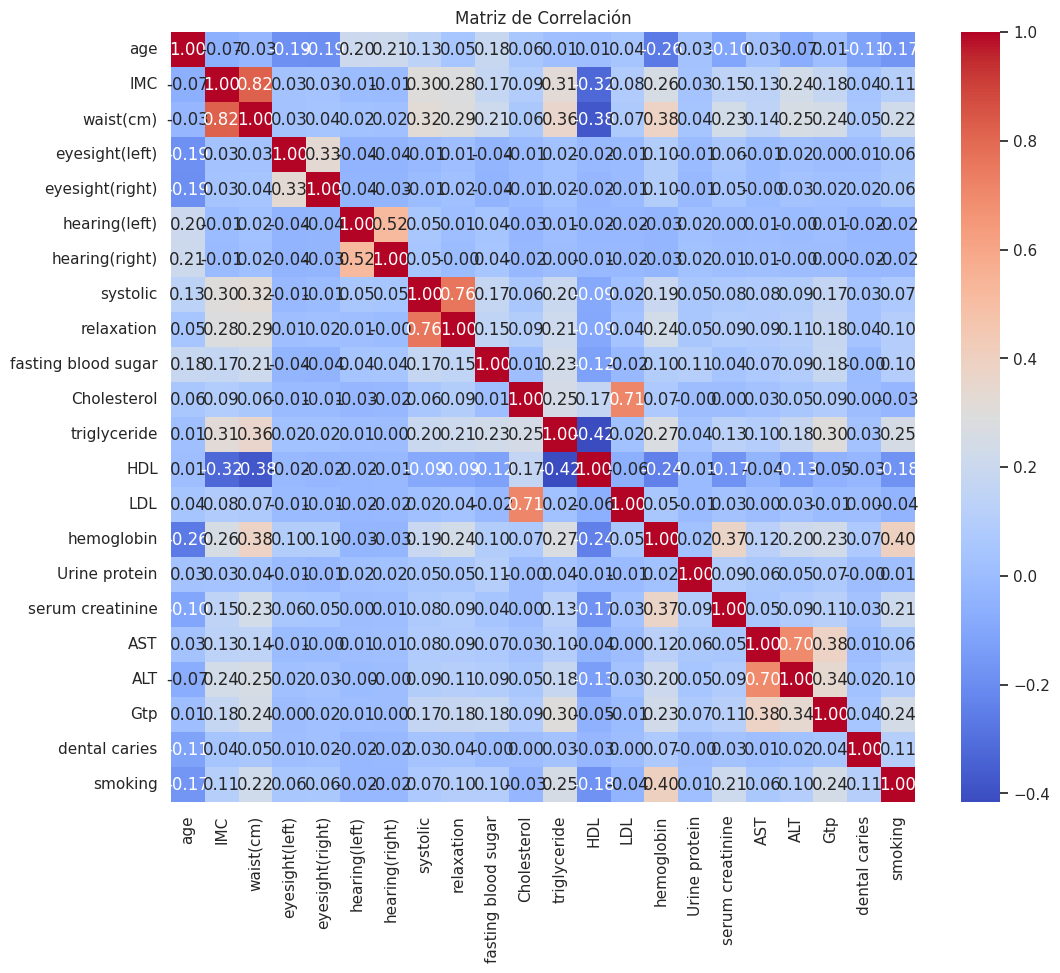

In [ ]:
# Suponiendo que ya has definido el DataFrame 'df' y seleccionado las columnas
columns = ['age', 'IMC', 'waist(cm)', 'eyesight(left)',
           'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic',
           'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride',
           'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST',
           'ALT', 'Gtp', 'dental caries', 'smoking']

selected_columns = df[columns]

# Calcular la matriz de correlación
correlation_matrix = selected_columns.corr()

# Configuración de la visualización
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()


PARA LA SEGUNDA ENTREGA(ETL)


# NULOS

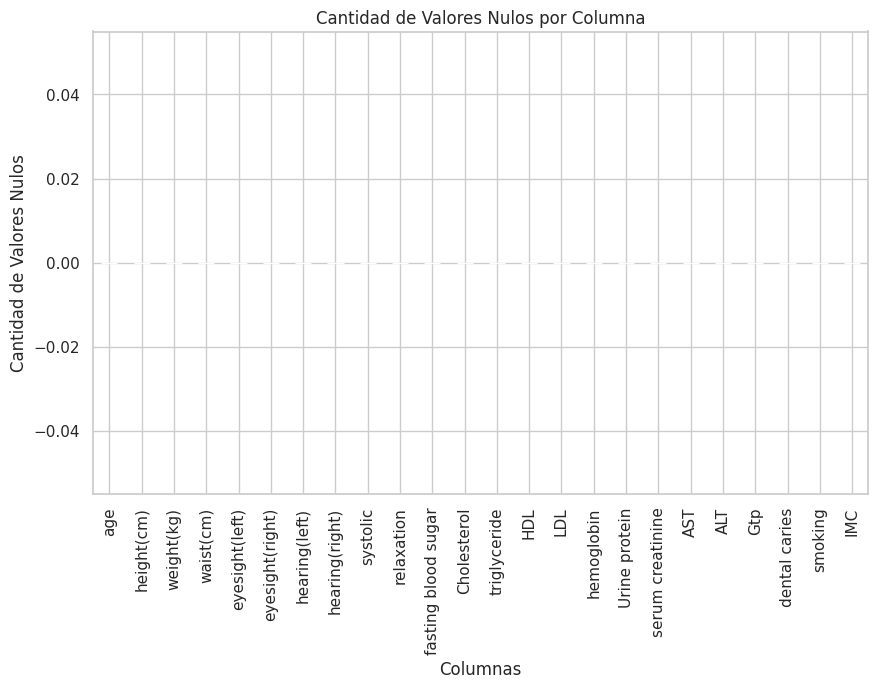

In [ ]:
#Grafico para visualizar la cantiad de nulos por columna

# Calcula la cantidad de valores nulos en cada columna
valores_nulos = df.isnull().sum()

# Crea un gráfico de barras
plt.figure(figsize=(10, 6))  # Ajusta el tamaño del gráfico según tus preferencias
valores_nulos.plot(kind='bar', color='red')

# Configura el título y etiquetas de los ejes
plt.title('Cantidad de Valores Nulos por Columna')
plt.xlabel('Columnas')
plt.ylabel('Cantidad de Valores Nulos')

# Muestra el gráfico
plt.show()


CONCLUSION: No contiene nulos el dataSet


# NUEVA COLUMNA IMC [kg/m²]

In [ ]:
#Se crea una columna que contiene el IMC
# Añadir una nueva columna 'IMC' al DataFrame
# {Bajo peso: IMC menor a 18.5} {Peso normal (saludable): IMC entre 18.5 y 24.9} {Sobrepeso: IMC entre 25 y 29.9}
# {Obesidad: IMC de 30 o superior}
df['IMC'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)
df['IMC'] = df['IMC'].round(2).astype(int)
# 'IMC' se calculará como peso en kg / (altura en metros)^2
df.head(10)

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,IMC
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,142,19.8,1,1.0,61,115,125,1,1,29
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,114,15.9,1,1.1,19,25,30,1,0,35
2,45,155,65,86.0,0.9,0.9,1,1,110,80,...,112,13.7,3,0.6,1090,1400,276,0,0,27
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,91,16.9,1,0.9,32,36,36,0,0,29
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,92,14.9,1,1.2,26,28,15,0,0,22
5,60,160,50,78.0,1.0,0.9,2,2,126,75,...,64,13.9,1,1.0,47,23,70,0,1,19
6,40,175,90,95.0,0.9,1.0,1,1,130,88,...,102,16.5,1,1.0,19,22,19,0,0,29
7,40,180,75,85.0,1.5,1.5,1,1,110,60,...,99,14.0,2,1.4,29,20,32,1,1,23
8,40,170,60,74.0,1.2,1.5,1,1,89,57,...,104,12.9,2,0.7,17,17,14,0,0,20
9,45,155,55,78.0,0.7,1.0,1,1,114,81,...,107,13.1,1,0.6,22,15,56,0,0,22


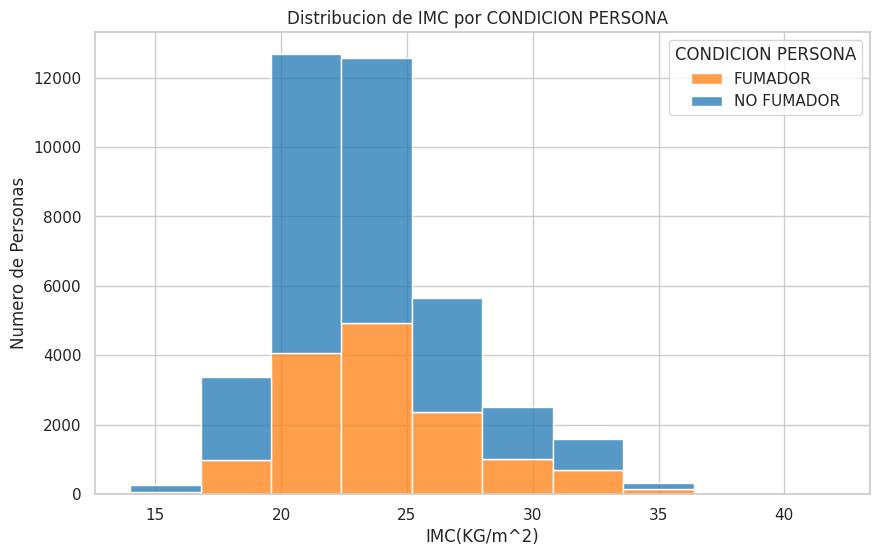

valores de IMC
Valor: 14, Frecuencia: 7
Valor: 15, Frecuencia: 45
Valor: 16, Frecuencia: 210
Valor: 17, Frecuencia: 647
Valor: 18, Frecuencia: 979
Valor: 19, Frecuencia: 1746
Valor: 20, Frecuencia: 3672
Valor: 21, Frecuencia: 2564
Valor: 22, Frecuencia: 6434
Valor: 23, Frecuencia: 3701
Valor: 24, Frecuencia: 5042
Valor: 25, Frecuencia: 3818
Valor: 26, Frecuencia: 1944
Valor: 27, Frecuencia: 3704
Valor: 28, Frecuencia: 339
Valor: 29, Frecuencia: 2013
Valor: 30, Frecuencia: 152
Valor: 31, Frecuencia: 983
Valor: 32, Frecuencia: 307
Valor: 33, Frecuencia: 295
Valor: 34, Frecuencia: 145
Valor: 35, Frecuencia: 112
Valor: 36, Frecuencia: 56
Valor: 37, Frecuencia: 37
Valor: 38, Frecuencia: 14
Valor: 39, Frecuencia: 8
Valor: 40, Frecuencia: 5
Valor: 41, Frecuencia: 3
Valor: 42, Frecuencia: 2


In [ ]:
# Create a histogram using seaborn with different colors for FUMADOR and NO FUMADOR
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df['IMC'], bins=10, kde=False, hue=df['smoking'] , multiple='stack', palette=['tab:blue', 'tab:orange'])
plt.xlabel('IMC(KG/m^2)')
plt.ylabel('Numero de Personas')
plt.title('Distribucion de IMC por CONDICION PERSONA  ')
plt.legend(title='CONDICION PERSONA', labels=['FUMADOR', 'NO FUMADOR'])
plt.grid(True)
plt.show()

# Calcular y ordenar las frecuencias de los valores en la columna "IMC"
frecuencias = df["IMC"].value_counts().sort_index()

# Mostrar los valores y sus frecuencias
print('valores de IMC')
for valor, frecuencia in frecuencias.items():
    print(f"Valor: {valor}, Frecuencia: {frecuencia}")



In [ ]:
#SE ELIMINARA LOS VALORES  DE ESTA COLUMNA QUE SEAN MAYORES A 39 y MENORES A 14  QUE NO AYUDA AL ANALISIS
df = df[(df["IMC"] < 39 )]
df = df[(df["IMC"] > 14 )]

# Eliminacion de altura y peso

In [ ]:
#Eliminando las columnas sobre la altura y el peso (se trabaja directamente sobre la columna IMC)
columnas_a_eliminar = ["height(cm)", "weight(kg)"]

# Utiliza el método drop para eliminar las columnas
df = df.drop(columns=columnas_a_eliminar)
df.head(10)


,age,waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,...,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,IMC
0,35,97.0,0.9,0.9,1,1,118,78,97,239,...,142,19.8,1,1.0,61,115,125,1,1,29
1,20,110.0,0.7,0.9,1,1,119,79,88,211,...,114,15.9,1,1.1,19,25,30,1,0,35
2,45,86.0,0.9,0.9,1,1,110,80,80,193,...,112,13.7,3,0.6,1090,1400,276,0,0,27
3,45,94.0,0.8,0.7,1,1,158,88,249,210,...,91,16.9,1,0.9,32,36,36,0,0,29
4,20,81.0,1.5,0.1,1,1,109,64,100,179,...,92,14.9,1,1.2,26,28,15,0,0,22
5,60,78.0,1.0,0.9,2,2,126,75,114,177,...,64,13.9,1,1.0,47,23,70,0,1,19
6,40,95.0,0.9,1.0,1,1,130,88,90,207,...,102,16.5,1,1.0,19,22,19,0,0,29
7,40,85.0,1.5,1.5,1,1,110,60,100,170,...,99,14.0,2,1.4,29,20,32,1,1,23
8,40,74.0,1.2,1.5,1,1,89,57,83,178,...,104,12.9,2,0.7,17,17,14,0,0,20
9,45,78.0,0.7,1.0,1,1,114,81,96,184,...,107,13.1,1,0.6,22,15,56,0,0,22


# ANALISIS DE EDAD

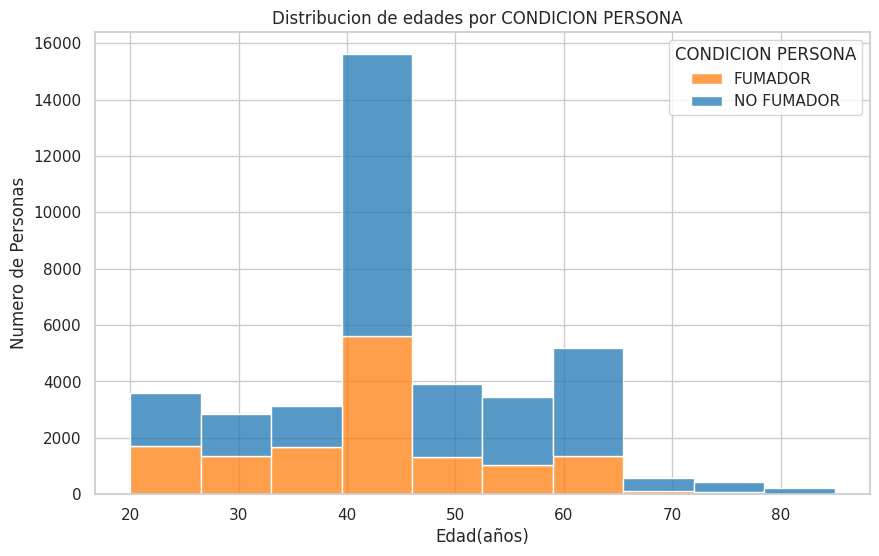

In [ ]:
# Create a histogram using seaborn with different colors for FUMADOR and NO FUMADOR
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df['age'], bins=10, kde=False, hue=df['smoking'] , multiple='stack', palette=['tab:blue', 'tab:orange'])
plt.xlabel('Edad(años)')
plt.ylabel('Numero de Personas')
plt.title('Distribucion de edades por CONDICION PERSONA  ')
plt.legend(title='CONDICION PERSONA', labels=['FUMADOR', 'NO FUMADOR'])
plt.grid(True)
plt.show()

In [ ]:
# Filtrar las filas donde 'smoking' es igual a 1 (fuman) y la edad está entre 70 y 90 años
fumadores_entre_70_y_90 = df[(df['smoking'] == 1) & (df['age'] >= 70) & (df['age'] <= 90)]

# Contar la cantidad de filas resultantes
cantidad_fumadores_entre_70_y_90 = len(fumadores_entre_70_y_90)

print("Cantidad de fumadores entre 70 y 90 años:", cantidad_fumadores_entre_70_y_90)

fumadores_entre_80_y_90 = df[(df['smoking'] == 1) & (df['age'] >= 80) & (df['age'] <= 90)]

# Contar la cantidad de filas resultantes
cantidad_fumadores_entre_80_y_90 = len(fumadores_entre_80_y_90)

print("Cantidad de fumadores entre 80 y 90 años:", cantidad_fumadores_entre_80_y_90)

# Filtrar las filas donde 'smoking' es igual a 0 (no fuman) y la edad está entre 80 y 90 años
no_fumadores_entre_80_y_90 = df[(df['smoking'] == 0) & (df['age'] >= 80) & (df['age'] <= 90)]

# Contar la cantidad de filas resultantes
cantidad_no_fumadores_entre_80_y_90 = len(no_fumadores_entre_80_y_90)

print("Cantidad de no fumadores entre 80 y 90 años:", cantidad_no_fumadores_entre_80_y_90)

Cantidad de fumadores entre 70 y 90 años: 202
Cantidad de fumadores entre 80 y 90 años: 24
Cantidad de no fumadores entre 80 y 90 años: 186


In [ ]:
#SE ELIMINARA LOS VALORES  DE ESTA COLUMNA QUE SEAN MAYORES A 80 QUE NO AYUDA AL ANALISIS
df = df[(df["age"] < 80 )]

# Análisis de los ojos

In [ ]:
# Calcular y ordenar las frecuencias de los valores en la columna "eyesight(left)"
frecuencias = df["eyesight(left)"].value_counts().sort_index()

# Mostrar los valores y sus frecuencias
print('valores de "eyesight(left)":')
for valor, frecuencia in frecuencias.items():
    print(f"Valor: {valor}, Frecuencia: {frecuencia}")

# Calcular y ordenar las frecuencias de los valores en la columna "eyesight(right)"
frecuencias = df["eyesight(right)"].value_counts().sort_index()

# Mostrar los valores y sus frecuencias
print('\nvalores de "eyesight(right)":')
for valor, frecuencia in frecuencias.items():
    print(f"Valor: {valor}, Frecuencia: {frecuencia}")

valores de "eyesight(left)":
Valor: 0.1, Frecuencia: 238
Valor: 0.2, Frecuencia: 299
Valor: 0.3, Frecuencia: 590
Valor: 0.4, Frecuencia: 836
Valor: 0.5, Frecuencia: 1447
Valor: 0.6, Frecuencia: 1761
Valor: 0.7, Frecuencia: 3071
Valor: 0.8, Frecuencia: 3571
Valor: 0.9, Frecuencia: 3571
Valor: 1.0, Frecuencia: 8592
Valor: 1.1, Frecuencia: 2
Valor: 1.2, Frecuencia: 8873
Valor: 1.3, Frecuencia: 9
Valor: 1.5, Frecuencia: 5520
Valor: 1.6, Frecuencia: 14
Valor: 1.8, Frecuencia: 1
Valor: 1.9, Frecuencia: 1
Valor: 2.0, Frecuencia: 286
Valor: 9.9, Frecuencia: 67

valores de "eyesight(right)":
Valor: 0.1, Frecuencia: 255
Valor: 0.2, Frecuencia: 346
Valor: 0.3, Frecuencia: 569
Valor: 0.4, Frecuencia: 913
Valor: 0.5, Frecuencia: 1506
Valor: 0.6, Frecuencia: 1664
Valor: 0.7, Frecuencia: 2952
Valor: 0.8, Frecuencia: 3700
Valor: 0.9, Frecuencia: 3671
Valor: 1.0, Frecuencia: 8708
Valor: 1.1, Frecuencia: 2
Valor: 1.2, Frecuencia: 8813
Valor: 1.3, Frecuencia: 5
Valor: 1.5, Frecuencia: 5301
Valor: 1.6, Fr

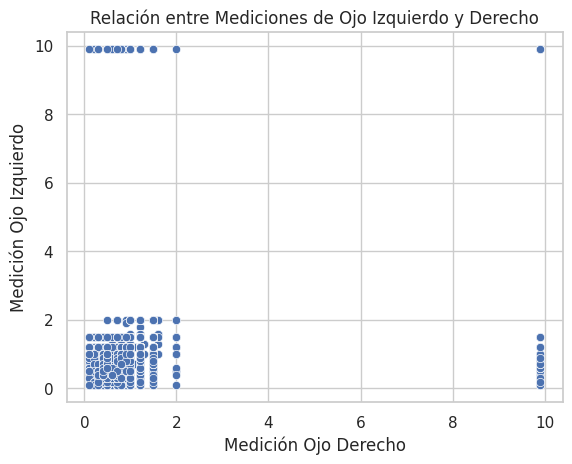

In [ ]:
# Supongamos que tienes un DataFrame df con columnas 'OjoIzquierdo' y 'OjoDerecho'
#vista ojo  {Leve: 0.50 a 3} {Moderado: 3.25 a 5.00.} {Alto: 5.25 a 10.} {Extrema: mayor que 10.}
sns.scatterplot(x='eyesight(right)', y='eyesight(left)', data=df)
plt.title('Relación entre Mediciones de Ojo Izquierdo y Derecho')
plt.xlabel('Medición Ojo Derecho')
plt.ylabel('Medición Ojo Izquierdo')
plt.show()

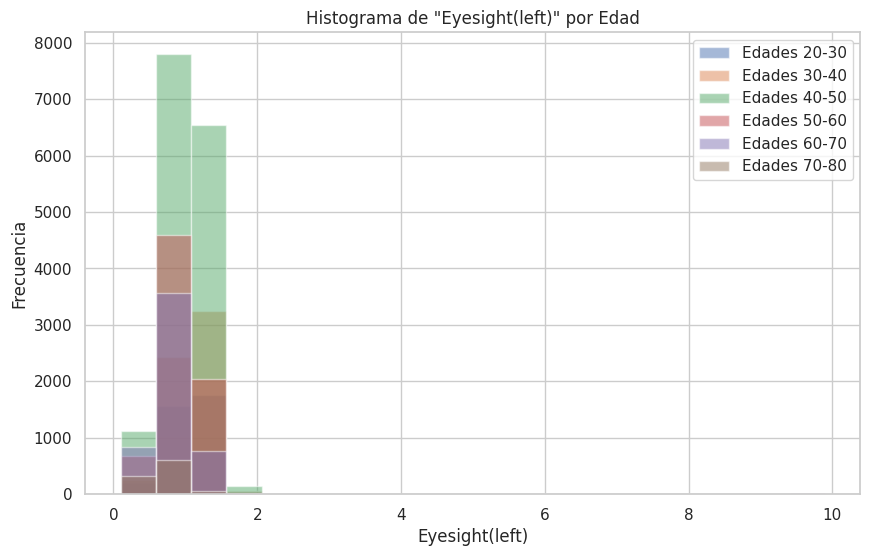

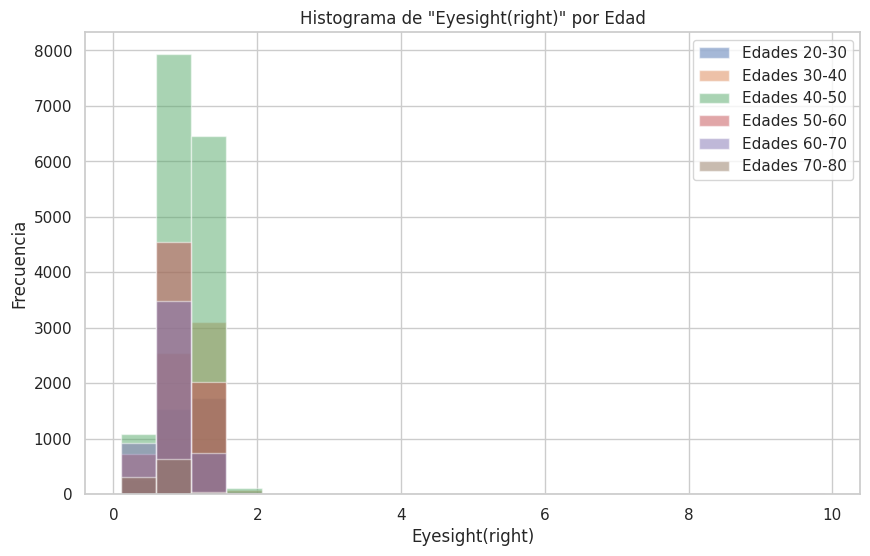

In [ ]:
# Definir los límites de los grupos de edades y el intervalo
edad_min = min(df['age'])  # Edad mínima en el DataFrame
edad_max = max(df['age'])  # Edad máxima en el DataFrame
intervalo_edad = 10  # Intervalo de edad deseado (5 años)

# Calcular el número de intervalos
num_intervalos = (edad_max - edad_min) // intervalo_edad + 1

# Crear un histograma
plt.figure(figsize=(10, 6))  # Ajusta el tamaño de la figura

# Iterar a través de los grupos de edades
for i in range(num_intervalos):
    edad_inferior = edad_min + i * intervalo_edad
    edad_superior = edad_min + (i + 1) * intervalo_edad

    # Filtrar el DataFrame para el grupo de edad actual
    grupo_edad = df[(df['age'] >= edad_inferior) & (df['age'] < edad_superior)]

    # Crear el histograma para "eyeslight(left)" en el grupo de edad actual
    plt.hist(grupo_edad['eyesight(left)'], bins=20, alpha=0.5, label=f'Edades {edad_inferior}-{edad_superior}')

# Configurar los límites de los ejes y agregar etiquetas
plt.xlabel('Eyesight(left)')
plt.ylabel('Frecuencia')
plt.title('Histograma de "Eyesight(left)" por Edad')
plt.legend()

# Mostrar el histograma
plt.show()

# Crear un histograma
plt.figure(figsize=(10, 6))  # Ajusta el tamaño de la figura

# Iterar a través de los grupos de edades
for i in range(num_intervalos):
    edad_inferior = edad_min + i * intervalo_edad
    edad_superior = edad_min + (i + 1) * intervalo_edad

    # Filtrar el DataFrame para el grupo de edad actual
    grupo_edad = df[(df['age'] >= edad_inferior) & (df['age'] < edad_superior)]

    # Crear el histograma para "eyeslight(left)" en el grupo de edad actual
    plt.hist(grupo_edad['eyesight(right)'], bins=20, alpha=0.5, label=f'Edades {edad_inferior}-{edad_superior}')

# Configurar los límites de los ejes y agregar etiquetas
plt.xlabel('Eyesight(right)')
plt.ylabel('Frecuencia')
plt.title('Histograma de "Eyesight(right)" por Edad')
plt.legend()

# Mostrar el histograma
plt.show()


histograma de las columnas "eyeslight(left)" y "eyeslight(right)" por edad - rangos de edad de 10:

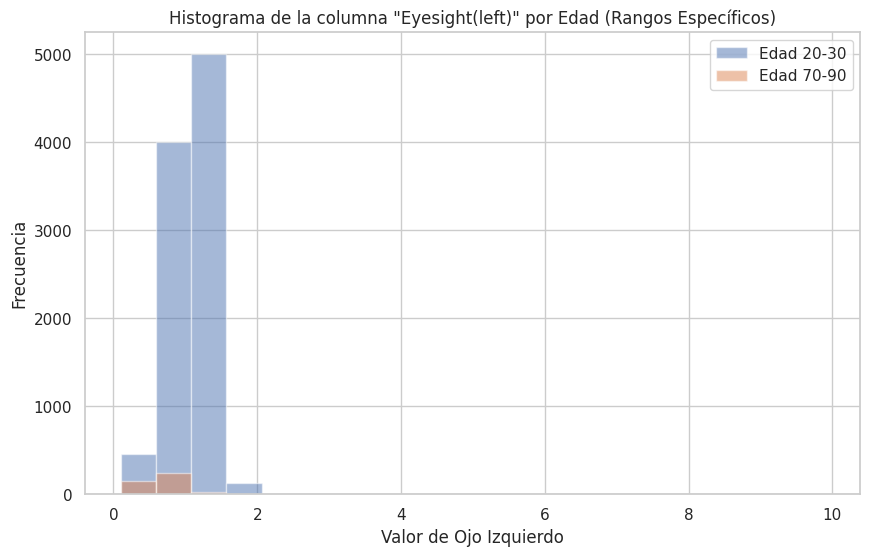

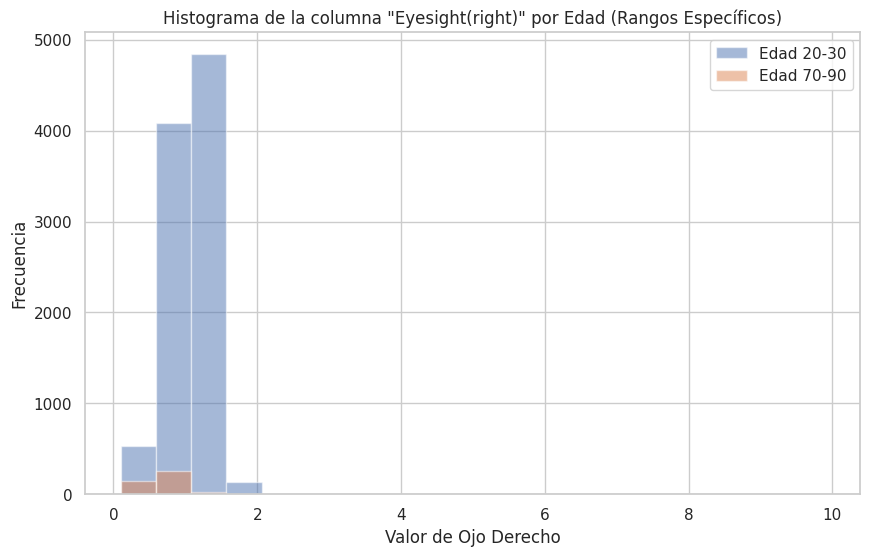

In [ ]:
# Filtrar el DataFrame para incluir solo las edades en los rangos deseados
age_range1 = df[(df['age'] >= 20) & (df['age'] <= 35)]
age_range2 = df[(df['age'] >= 75) & (df['age'] <= 90)]

# COLUMNA "eyeslight(left)"
# Crear un histograma
plt.figure(figsize=(10, 6))  # Ajusta el tamaño de la figura

# Crear el histograma para el primer rango de edades (20-30)
plt.hist(age_range1['eyesight(left)'], bins=20, alpha=0.5, label='Edad 20-30')

# Crear el histograma para el segundo rango de edades (70-90)
plt.hist(age_range2['eyesight(left)'], bins=20, alpha=0.5, label='Edad 70-90')

# Agregar etiquetas y leyenda
plt.xlabel('Valor de Ojo Izquierdo')
plt.ylabel('Frecuencia')
plt.title('Histograma de la columna "Eyesight(left)" por Edad (Rangos Específicos)')
plt.legend()

# Mostrar el histograma
plt.show()

# COLUMNA "eyeslight(right)"
# Crear un histograma
plt.figure(figsize=(10, 6))  # Ajusta el tamaño de la figura

# Crear el histograma para el primer rango de edades (20-30)
plt.hist(age_range1['eyesight(right)'], bins=20, alpha=0.5, label='Edad 20-30')

# Crear el histograma para el segundo rango de edades (70-90)
plt.hist(age_range2['eyesight(right)'], bins=20, alpha=0.5, label='Edad 70-90')

# Agregar etiquetas y leyenda
plt.xlabel('Valor de Ojo Derecho')
plt.ylabel('Frecuencia')
plt.title('Histograma de la columna "Eyesight(right)" por Edad (Rangos Específicos)')
plt.legend()

# Mostrar el histograma
plt.show()


análisis de las columnas con los rangos de edades de los mas jovenes (20-35) y el de los mas viejos (75-90):

In [ ]:
#SE ELIMINARA LOS VALORES  DE ESTA COLUMNA QUE ESTEN FUERA DEL RANGO (9.9) PORQUE SON VALORES ATIPICOS Y MENORES Y NO AYUDA AL ANALISIS
# Filtrar el DataFrame para incluir solo los valores dentro del rango deseado
df = df[(df["eyesight(left)"] >= 0.0) & (df["eyesight(left)"] <= 2.0)]

# Filtrar el DataFrame para incluir solo los valores dentro del rango deseado
df = df[(df["eyesight(right)"] >= 0.0) & (df["eyesight(right)"] <= 2.0)]

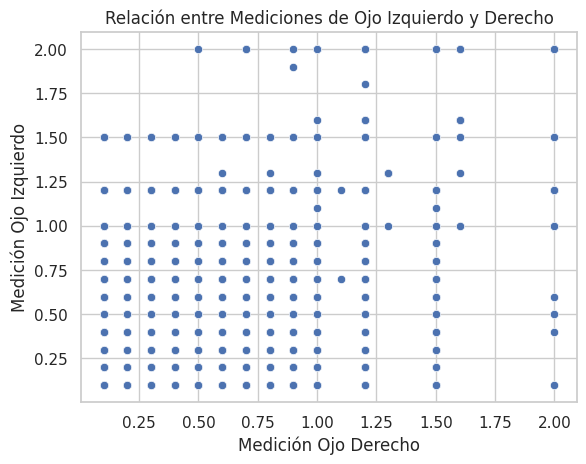

In [ ]:
# Supongamos que tienes un DataFrame df con columnas 'OjoIzquierdo' y 'OjoDerecho'
#vista ojo  {Leve: 0.50 a 3} {Moderado: 3.25 a 5.00.} {Alto: 5.25 a 10.} {Extrema: mayor que 10.}
sns.scatterplot(x='eyesight(right)', y='eyesight(left)', data=df)
plt.title('Relación entre Mediciones de Ojo Izquierdo y Derecho')
plt.xlabel('Medición Ojo Derecho')
plt.ylabel('Medición Ojo Izquierdo')
plt.show()

# Eliminación de cintura y orejas

In [ ]:
#Se eliminan las columas sobre la medicion de la cintura (waist(cm)) y los oidos tanto izquierdo como derecho
#Ya que las mismas no nos proporciona informacion valiosa para la hipotesis planteada
#
columnas_a_eliminar = ["waist(cm)", "hearing(left)", "hearing(right)"]

df = df.drop(columnas_a_eliminar, axis=1)

df.head(3)

,age,eyesight(left),eyesight(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,IMC
0,35,0.9,0.9,118,78,97,239,153,70,142,19.8,1,1.0,61,115,125,1,1,29
1,20,0.7,0.9,119,79,88,211,128,71,114,15.9,1,1.1,19,25,30,1,0,35
2,45,0.9,0.9,110,80,80,193,120,57,112,13.7,3,0.6,1090,1400,276,0,0,27


# Análisis de presión sistolica

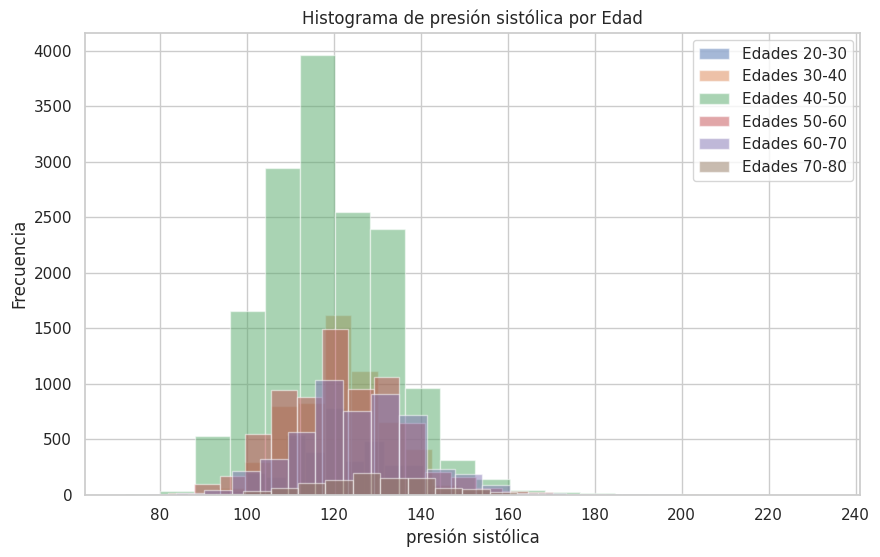

In [ ]:
#{Baja: Menos de 90 mm Hg}
#{Normal: Menos de 120 mm Hg} {Normal alta (elevada): 120-129 mm Hg} {Hipertensión de grado 1: 130-139 mm Hg}
#{Hipertensión de grado 2: 140 mm Hg o más}

# Definir los límites de los grupos de edades y el intervalo
edad_min = min(df['age'])  # Edad mínima en el DataFrame
edad_max = max(df['age'])  # Edad máxima en el DataFrame
intervalo_edad = 10  # Intervalo de edad deseado (5 años)

# Calcular el número de intervalos
num_intervalos = (edad_max - edad_min) // intervalo_edad + 1

# Crear un histograma
plt.figure(figsize=(10, 6))  # Ajusta el tamaño de la figura

# Iterar a través de los grupos de edades
for i in range(num_intervalos):
    edad_inferior = edad_min + i * intervalo_edad
    edad_superior = edad_min + (i + 1) * intervalo_edad

    # Filtrar el DataFrame para el grupo de edad actual
    grupo_edad = df[(df['age'] >= edad_inferior) & (df['age'] < edad_superior)]

    # Crear el histograma para "eyeslight(left)" en el grupo de edad actual
    plt.hist(grupo_edad['systolic'], bins=20, alpha=0.5, label=f'Edades {edad_inferior}-{edad_superior}')

# Configurar los límites de los ejes y agregar etiquetas
plt.xlabel('presión sistólica')
plt.ylabel('Frecuencia')
plt.title('Histograma de presión sistólica por Edad')
plt.legend()

# Mostrar el histograma
plt.show()


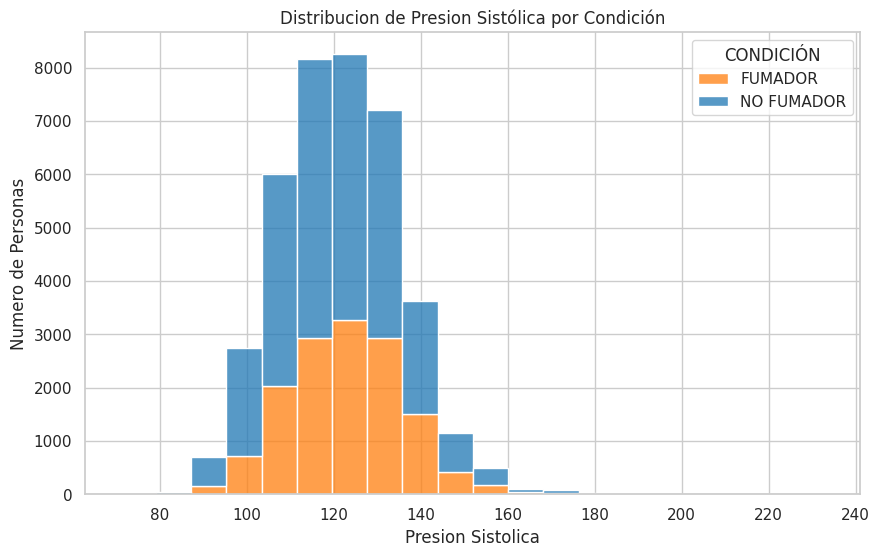

In [ ]:
# Definir los límites de los grupos de edades y el intervalo
# Create a histogram using seaborn with different colors for FUMADOR and NO FUMADOR
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df['systolic'], bins=20, kde=False, hue=df['smoking'] , multiple='stack', palette=['tab:blue', 'tab:orange'])
plt.xlabel('Presion Sistolica')
plt.ylabel('Numero de Personas')
plt.title('Distribucion de Presion Sistólica por Condición')
plt.legend(title='CONDICIÓN', labels=['FUMADOR', 'NO FUMADOR'])
plt.grid(True)
plt.show()

# análisis presion diastólica (**relaxation**)

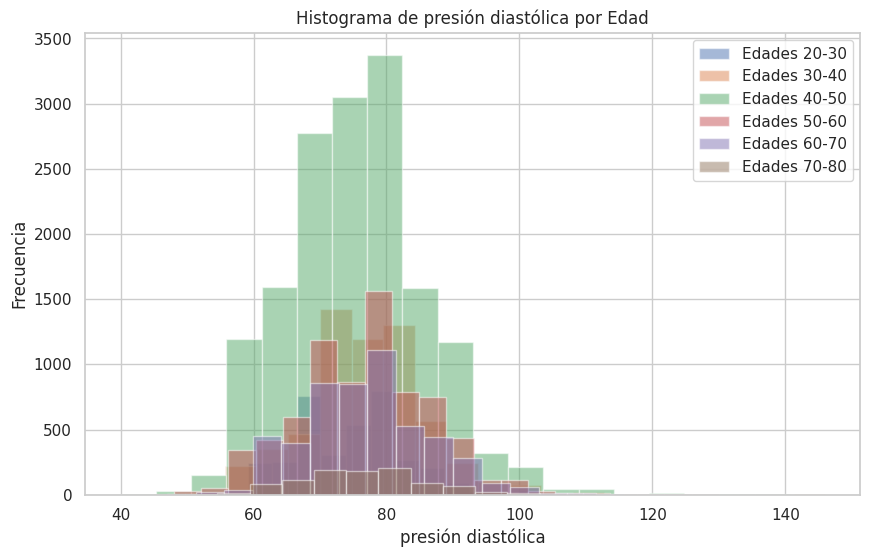

In [ ]:
#Presión arterial normal: Menos de 80 mm Hg
#Presión arterial elevada: 80-89 mm Hg
#Hipertensión de grado 1: 90-99 mm Hg
#Hipertensión de grado 2: 100 mm Hg o más

# Definir los límites de los grupos de edades y el intervalo
edad_min = min(df['age'])  # Edad mínima en el DataFrame
edad_max = max(df['age'])  # Edad máxima en el DataFrame
intervalo_edad = 10  # Intervalo de edad deseado (5 años)

# Calcular el número de intervalos
num_intervalos = (edad_max - edad_min) // intervalo_edad + 1

# Crear un histograma
plt.figure(figsize=(10, 6))  # Ajusta el tamaño de la figura

# Iterar a través de los grupos de edades
for i in range(num_intervalos):
    edad_inferior = edad_min + i * intervalo_edad
    edad_superior = edad_min + (i + 1) * intervalo_edad

    # Filtrar el DataFrame para el grupo de edad actual
    grupo_edad = df[(df['age'] >= edad_inferior) & (df['age'] < edad_superior)]

    # Crear el histograma para "eyeslight(left)" en el grupo de edad actual
    plt.hist(grupo_edad['relaxation'], bins=20, alpha=0.5, label=f'Edades {edad_inferior}-{edad_superior}')

# Configurar los límites de los ejes y agregar etiquetas
plt.xlabel('presión diastólica')
plt.ylabel('Frecuencia')
plt.title('Histograma de presión diastólica por Edad')
plt.legend()

# Mostrar el histograma
plt.show()

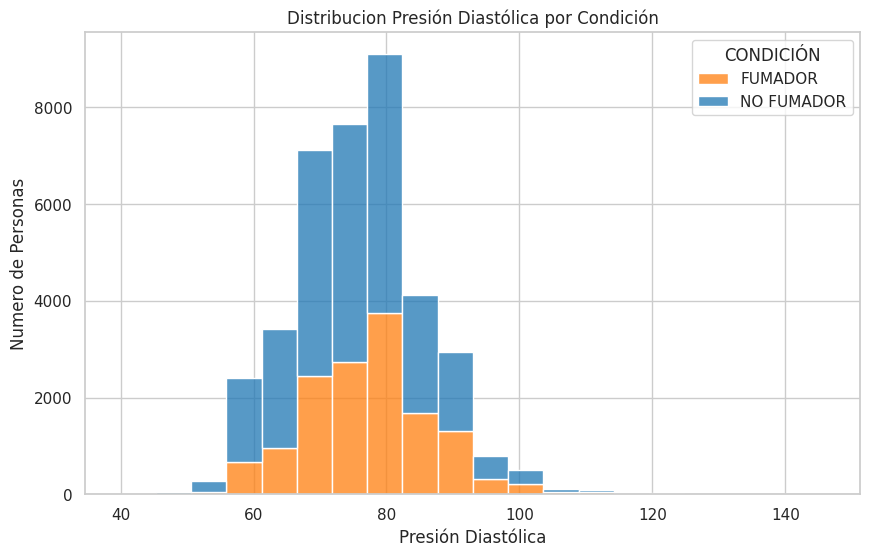

In [ ]:
# Definir los límites de los grupos de edades y el intervalo
# Create a histogram using seaborn with different colors for FUMADOR and NO FUMADOR
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df['relaxation'], bins=20, kde=False, hue=df['smoking'] , multiple='stack', palette=['tab:blue', 'tab:orange'])
plt.xlabel('Presión Diastólica')
plt.ylabel('Numero de Personas')
plt.title('Distribucion Presión Diastólica por Condición')
plt.legend(title='CONDICIÓN', labels=['FUMADOR', 'NO FUMADOR'])
plt.grid(True)
plt.show()

In [ ]:
#Valores atipicos: menores a 50 y mayores a 110
df = df[(df['relaxation'] >= 50) & (df['relaxation'] <= 110)]

# Análisis de azúcar en sangre

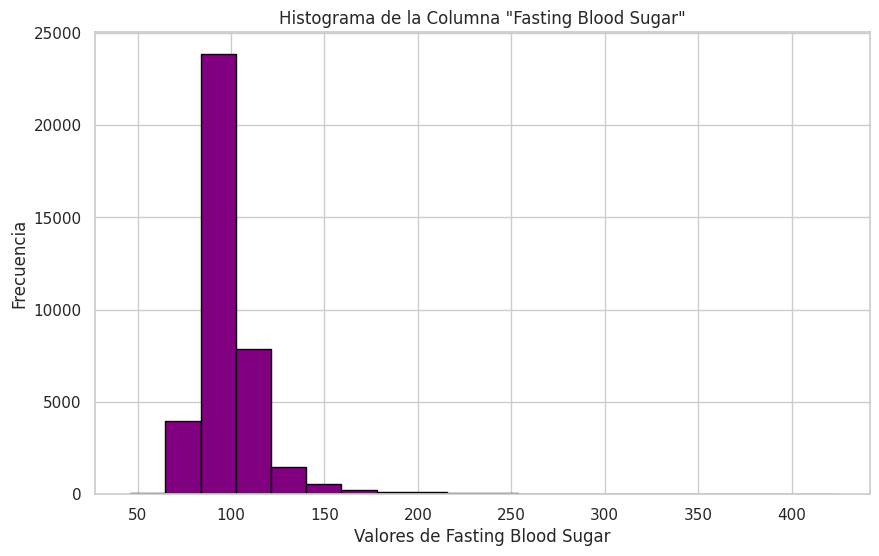

In [ ]:
#En ayunas:

#Normal: Menos de 100 mg/dL
#Prediabetes (glucosa en ayunas alterada): 100-125 mg/dL
#Diabetes: 126 mg/dL o más

#Dos horas después de comer (glucosa posprandial):

#Normal: Menos de 140 mg/dL
#Prediabetes: 140-199 mg/dL
#Diabetes: 200 mg/dL o más

blood_sugar_data = df['fasting blood sugar']

# Configura el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crea el histograma
plt.hist(blood_sugar_data, bins=20, color='purple', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Histograma de la Columna "Fasting Blood Sugar"')
plt.xlabel('Valores de Fasting Blood Sugar')
plt.ylabel('Frecuencia')

# Muestra el histograma
plt.show()



In [ ]:
df = df[(df['fasting blood sugar'] >= 60) & (df['fasting blood sugar'] <= 175)]

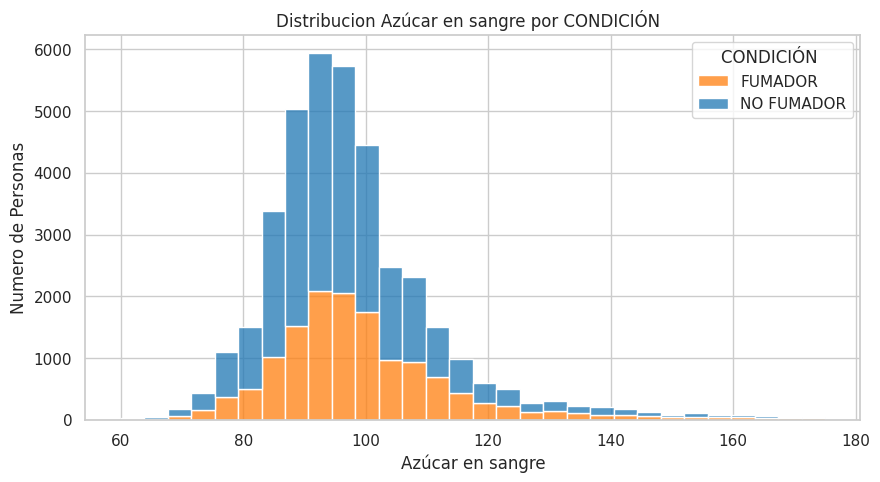

In [ ]:
# Definir los límites de los grupos de edades y el intervalo
# Create a histogram using seaborn with different colors for FUMADOR and NO FUMADOR
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x=df['fasting blood sugar'], bins=30, kde=False, hue=df['smoking'] , multiple='stack', palette=['tab:blue', 'tab:orange'])
plt.xlabel('Azúcar en sangre')
plt.ylabel('Numero de Personas')
plt.title('Distribucion Azúcar en sangre por CONDICIÓN  ')
plt.legend(title='CONDICIÓN ', labels=['FUMADOR', 'NO FUMADOR'])
plt.grid(True)
plt.show()

# Análisis de cholesterol

199    469
192    460
178    456
187    449
198    449
      ... 
445      1
346      1
97       1
90       1
363      1
Name: Cholesterol, Length: 277, dtype: int64


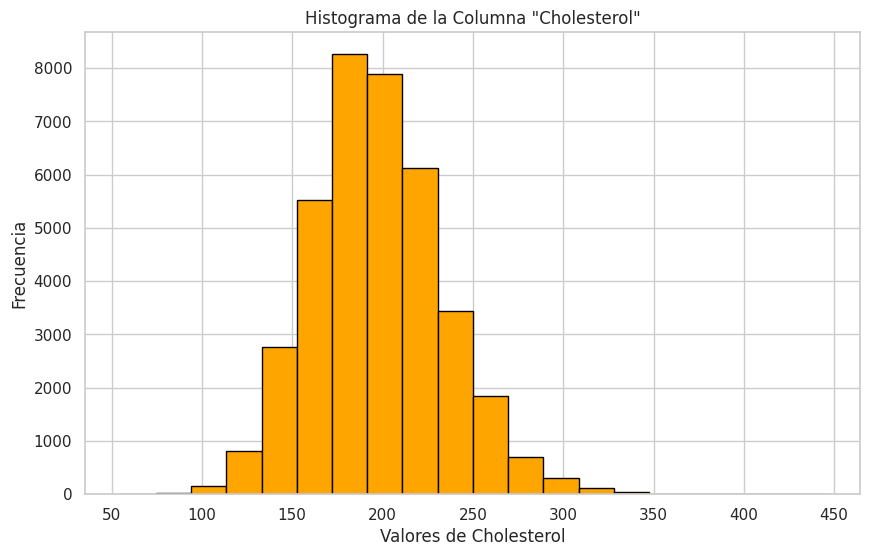

In [ ]:
#Deseable: Menos de 200 mg/dL
#Límite superior normal: 200-239 mg/dL
#Alto: 240 mg/dL o más
print(df["Cholesterol"].value_counts())

cholesterol_data = df['Cholesterol']

# Configura el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crea el histograma
plt.hist(cholesterol_data, bins=20, color='orange', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Histograma de la Columna "Cholesterol"')
plt.xlabel('Valores de Cholesterol')
plt.ylabel('Frecuencia')

# Muestra el histograma
plt.show()

In [ ]:
df = df[(df['Cholesterol'] >= 90) & (df['Cholesterol'] <= 330)]

# Análisis Triglicéridos

71     365
82     356
85     350
79     342
68     323
      ... 
11       1
19       1
8        1
548      1
999      1
Name: triglyceride, Length: 389, dtype: int64


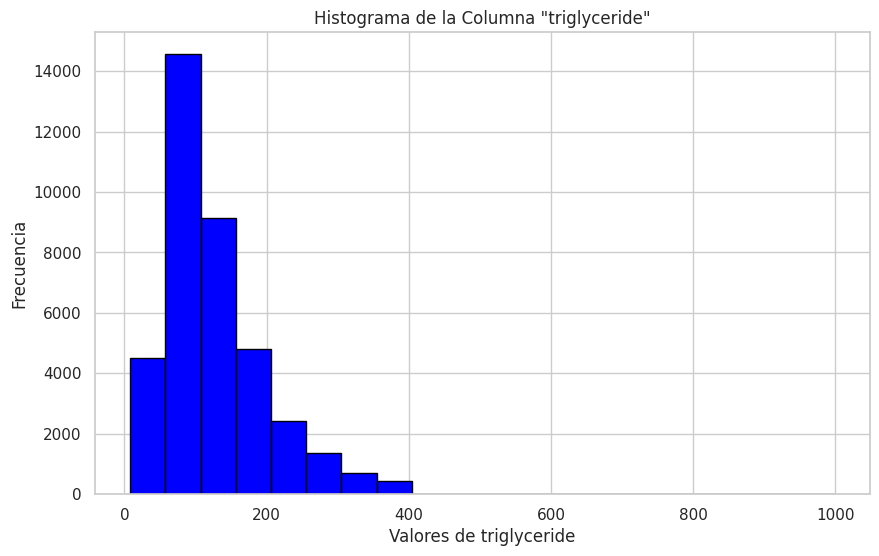

In [ ]:
#Normal: Menos de 150 mg/dL
#Borde alto (elevado): 150-199 mg/dL
#Alto: 200-499 mg/dL
#Muy alto: 500 mg/dL o más

print(df["triglyceride"].value_counts())
# Supongamos que tienes un DataFrame llamado 'df' y quieres hacer un histograma de la columna 'triglyceride'
triglyceride_data = df['triglyceride']

# Configura el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crea el histograma
plt.hist(triglyceride_data, bins=20, color='blue', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Histograma de la Columna "triglyceride"')
plt.xlabel('Valores de triglyceride')
plt.ylabel('Frecuencia')

# Muestra el histograma
plt.show()

In [ ]:
df = df[(df['triglyceride'] >= 40) & (df['triglyceride'] <= 410)]

# Análisis de HDL(colesterol bueno)

50     1143
55     1124
51     1121
54     1120
47     1100
       ... 
128       1
157       1
155       1
359       1
4         1
Name: HDL, Length: 122, dtype: int64


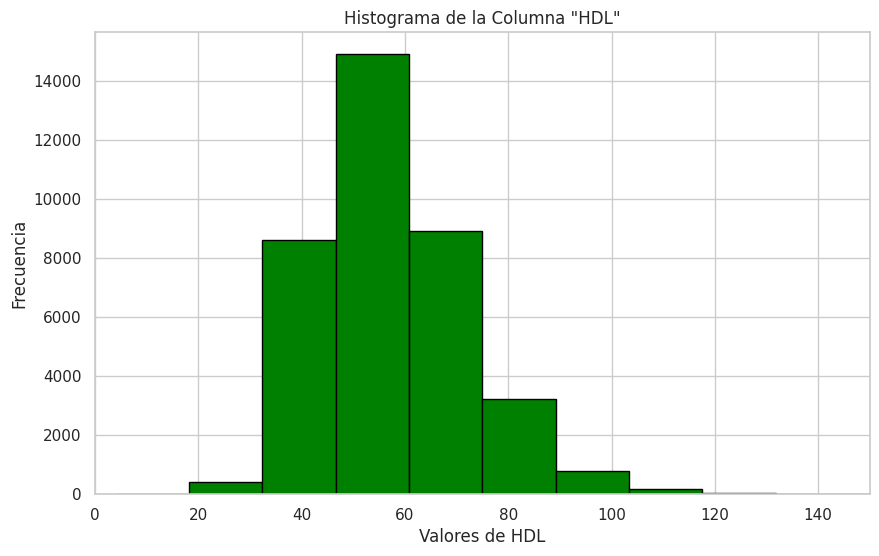

Frecuencia de valores en 'HDL' en el rango de 120 a 130:
122    9
121    8
125    7
123    5
124    4
120    3
127    2
129    2
128    1
130    1
Name: HDL, dtype: int64
Frecuencia de valores en 'HDL' en el rango de 15 a 25:
25    13
24     9
23     3
18     3
22     3
21     1
Name: HDL, dtype: int64


In [ ]:
#HDL (colesterol bueno):

#Bajo: Menos de 40 mg/dL (para hombres y mujeres)
#Alto: 60 mg/dL o más (considerado protector contra las enfermedades cardíacas)

print(df["HDL"].value_counts())

#import matplotlib.pyplot as plt

# Supongamos que tienes un DataFrame llamado 'df' y quieres hacer un histograma de la columna 'HDL'
hdl_data = df['HDL']

# Configura el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crea el histograma
plt.hist(hdl_data, bins=25, color='green', edgecolor='black')

# Establece los límites del eje x
plt.xlim(0, 150)  # Establece los límites desde 0 hasta 150

# Configura los títulos y etiquetas
plt.title('Histograma de la Columna "HDL"')
plt.xlabel('Valores de HDL')
plt.ylabel('Frecuencia')

# Muestra el histograma
plt.show()

# Supongamos que tienes un DataFrame llamado 'df' y quieres contar la frecuencia de valores en 'HDL' en el rango de 120 a 130
condicion = (df['HDL'] >= 120) & (df['HDL'] <= 130)

# Filtra las filas que cumplen con la condición y luego cuenta la frecuencia de cada valor
frecuencia_valores = df.loc[condicion, 'HDL'].value_counts()

print("Frecuencia de valores en 'HDL' en el rango de 120 a 130:")
print(frecuencia_valores)

# Supongamos que tienes un DataFrame llamado 'df' y quieres contar la frecuencia de valores en 'HDL' en el rango de 15 a 25
condicion = (df['HDL'] >= 15) & (df['HDL'] <= 25)

# Filtra las filas que cumplen con la condición y luego cuenta la frecuencia de cada valor
frecuencia_valores = df.loc[condicion, 'HDL'].value_counts()

print("Frecuencia de valores en 'HDL' en el rango de 15 a 25:")
print(frecuencia_valores)


In [ ]:
df = df[(df['HDL'] >= 23) & (df['HDL'] <= 126)]

# Análisis de LDL(colesterol malo)

112     498
110     488
106     482
107     481
108     462
       ... 
1560      1
244       1
1810      1
20        1
13        1
Name: LDL, Length: 254, dtype: int64


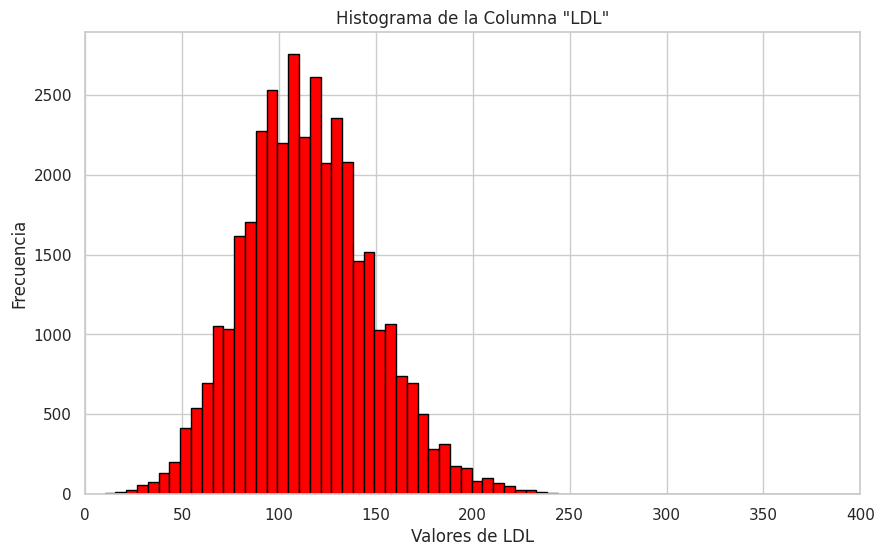

Frecuencia de valores en 'LDL' mayores a 200:
207     25
201     23
206     19
205     19
204     18
        ..
1560     1
244      1
1810     1
1010     1
1860     1
Name: LDL, Length: 61, dtype: int64
Frecuencia de valores en 'LDL' menores a 50:
49    61
47    55
46    41
48    38
45    37
44    30
42    29
41    24
36    24
43    22
38    22
32    22
40    20
39    19
35    17
37    16
34    12
33    10
29    10
27     8
25     8
22     7
26     7
28     7
21     6
30     6
31     5
16     4
15     3
1      3
23     3
12     3
19     3
24     2
7      2
17     2
10     2
20     1
4      1
18     1
9      1
13     1
Name: LDL, dtype: int64


In [ ]:
#LDL (colesterol malo):
#Óptimo: Menos de 100 mg/dL
#Cerca del óptimo: 100-129 mg/dL
#Límite superior normal: 130-159 mg/dL
#Alto: 160-189 mg/dL
#Muy alto: 190 mg/dL o más

print(df["LDL"].value_counts())

# Supongamos que tienes un DataFrame llamado 'df' y quieres hacer un histograma de la columna 'LDL'
ldl_data = df['LDL']

# Configura el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crea el histograma con más divisiones (bins) y un rango más pequeño en el eje x
plt.hist(ldl_data, bins=70, range=(10, 400), color='red', edgecolor='black')

# Establece los límites del eje x
plt.xlim(0, 400)  # Establece los límites desde 10 hasta 400

# Configura los títulos y etiquetas
plt.title('Histograma de la Columna "LDL"')
plt.xlabel('Valores de LDL')
plt.ylabel('Frecuencia')

# Muestra el histograma
plt.show()

# Supongamos que tienes un DataFrame llamado 'df'
# Crea una condición booleana para seleccionar las filas cuyo valor en 'LDL' sea mayor a 200
condicion = df['LDL'] > 200

# Filtra las filas según la condición
filas_filtradas = df[condicion]

# Utiliza value_counts() para contar la frecuencia de cada valor en 'LDL' que sea mayor a 200
frecuencia_valores = filas_filtradas['LDL'].value_counts()

print("Frecuencia de valores en 'LDL' mayores a 200:")
print(frecuencia_valores)

# Supongamos que tienes un DataFrame llamado 'df'
# Crea una condición booleana para seleccionar las filas cuyo valor en 'LDL' sea menor a 50
condicion = df['LDL'] < 50

# Filtra las filas según la condición
filas_filtradas = df[condicion]

# Utiliza value_counts() para contar la frecuencia de cada valor en 'LDL' que sea menor a 50
frecuencia_valores = filas_filtradas['LDL'].value_counts()

print("Frecuencia de valores en 'LDL' menores a 50:")
print(frecuencia_valores)

In [ ]:
df = df[(df['LDL'] >= 25) & (df['LDL'] <= 210)]

# Análisis de Hemoglobina

15.4    1045
15.6    1008
15.0    1000
15.3     992
15.7     980
        ... 
20.9       1
6.2        1
6.1        1
21.1       1
20.4       1
Name: hemoglobin, Length: 143, dtype: int64


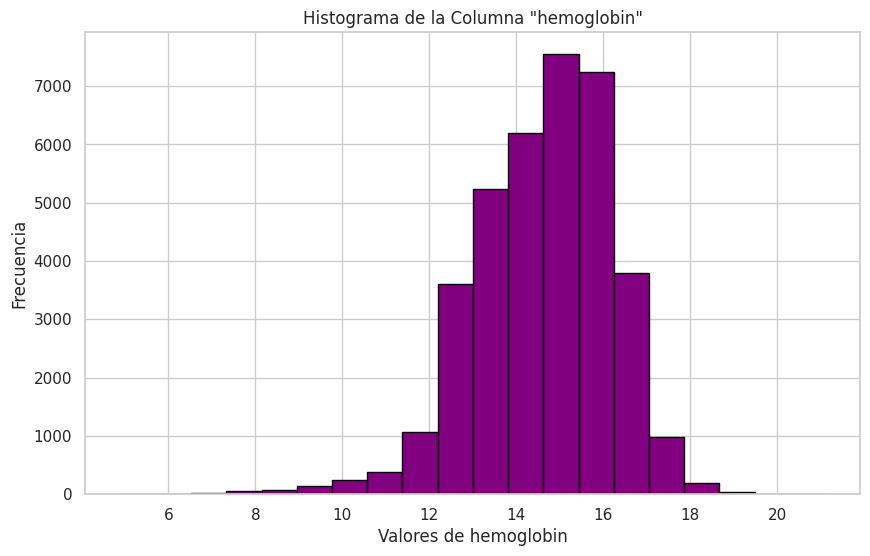

In [ ]:
#Adultos:
#Hombres: 13.8 a 17.2 g/dL
#Mujeres: 12.1 a 15.1 g/dL

print(df["hemoglobin"].value_counts())

# Supongamos que tienes un DataFrame llamado 'df' y quieres hacer un histograma de la columna 'hemoglobin'
hemoglobin_data = df['hemoglobin']

# Configura el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crea el histograma
plt.hist(hemoglobin_data, bins=20, color='purple', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Histograma de la Columna "hemoglobin"')
plt.xlabel('Valores de hemoglobin')
plt.ylabel('Frecuencia')

# Muestra el histograma
plt.show()

In [ ]:
df = df[(df['hemoglobin'] >= 8) & (df['hemoglobin'] <= 19)]

# Análisis de proteina de orina

1    34755
2     1165
3      586
4      149
5       44
6        3
Name: Urine protein, dtype: int64


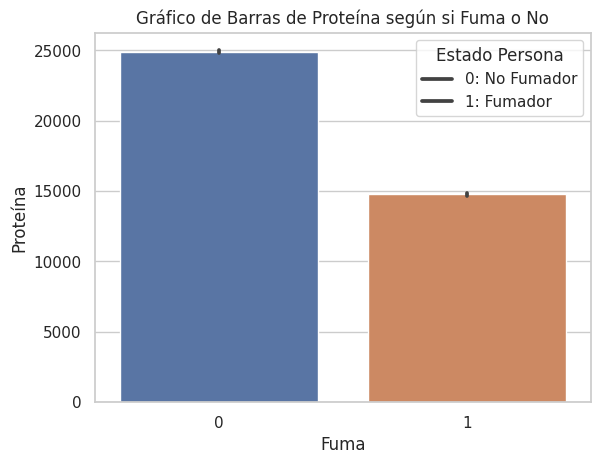

In [ ]:
#Proteína en orina (muestra aleatoria):
#Normal: Menos de 150 mg/dL o 0.15 g/L

#Proteína en orina (muestra de orina de 24 horas):
#Normal: Menos de 150 mg en 24 horas
print(df["Urine protein"].value_counts())

# Configurar el estilo de seaborn (opcional)
sns.set(style="whitegrid")

# Crear un gráfico de barras que muestra la media de 'proteina' según si fuma o no
sns.barplot(x='smoking', y='Urine protein', data=df, estimator=sum)  # Puedes cambiar 'sum' por 'mean' si deseas la media

# Añadir etiquetas y título
plt.xlabel('Fuma')
plt.ylabel('Proteína')
plt.title('Gráfico de Barras de Proteína según si Fuma o No')
plt.legend(title='Estado Persona', labels=["0: No Fumador","1: Fumador"], loc='upper right')

# Mostrar el gráfico
plt.show()

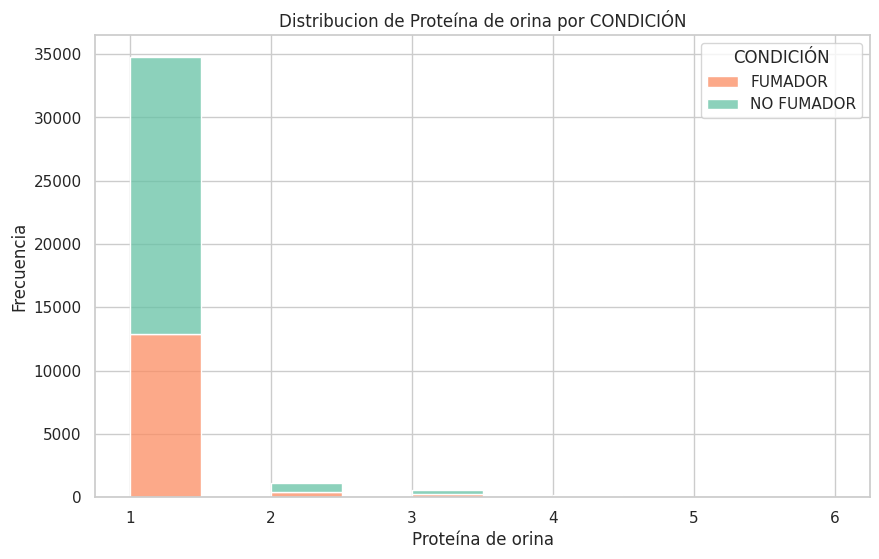

       age  eyesight(left)  eyesight(right)  systolic  relaxation  \
1       20             0.7              0.9       119          79   
2       45             0.9              0.9       110          80   
4       20             1.5              0.1       109          64   
5       60             1.0              0.9       126          75   
6       40             0.9              1.0       130          88   
...    ...             ...              ...       ...         ...   
38979   40             0.4              0.6       107          60   
38980   45             1.5              1.2       126          72   
38981   40             0.6              0.5       141          85   
38982   40             1.5              1.5        95          69   
38983   55             1.0              1.0       114          66   

       fasting blood sugar  Cholesterol  triglyceride  HDL  LDL  hemoglobin  \
1                       88          211           128   71  114        15.9   
2            

In [ ]:
# Create a histogram using seaborn with different colors for FUMADOR and NO FUMADOR
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df['Urine protein'], bins=10,  hue=df['smoking'] , multiple='stack', palette='Set2')
plt.xlabel('Proteína de orina')
plt.ylabel('Frecuencia')
plt.title('Distribucion de Proteína de orina por CONDICIÓN')
plt.legend(title='CONDICIÓN', labels=['FUMADOR', 'NO FUMADOR'])
plt.show()
print(df)

In [ ]:
# Se deberia eliminar la columna, ya que no se aclara que unidad de medicion se plantea para el analisis de esta variable.
# Ademas, los valores que aparecen en el dataset no respetan la distribucion correcta para analizar el estado de
# salud para esta columna (de 0 a 150 mg/dL o 0.15 g/L si esta en condiciones, de 150 o mas si tiene problemas)
df.drop(columns = "Urine protein")

,age,eyesight(left),eyesight(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,serum creatinine,AST,ALT,Gtp,dental caries,smoking,IMC
1,20,0.7,0.9,119,79,88,211,128,71,114,15.9,1.1,19,25,30,1,0,35
2,45,0.9,0.9,110,80,80,193,120,57,112,13.7,0.6,1090,1400,276,0,0,27
4,20,1.5,0.1,109,64,100,179,200,47,92,14.9,1.2,26,28,15,0,0,22
5,60,1.0,0.9,126,75,114,177,74,98,64,13.9,1.0,47,23,70,0,1,19
6,40,0.9,1.0,130,88,90,207,331,39,102,16.5,1.0,19,22,19,0,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38979,40,0.4,0.6,107,60,93,144,53,61,72,12.3,0.5,18,18,21,1,0,22
38980,45,1.5,1.2,126,72,91,227,100,76,131,12.5,0.6,23,11,12,0,0,22
38981,40,0.6,0.5,141,85,115,225,196,48,138,17.1,0.8,24,23,35,1,1,36
38982,40,1.5,1.5,95,69,102,206,48,79,116,12.0,0.6,24,20,17,0,1,21


# Análisis de Serum Creatinine

0.9     7511
0.8     6920
1.0     6473
0.7     4854
1.1     4075
0.6     2925
1.2     1920
0.5      954
1.3      605
1.4      191
0.4      131
1.5       54
1.6       25
0.1       14
1.7       11
1.8        8
0.3        6
1.9        3
2.1        3
2.0        3
3.4        2
7.4        2
2.6        2
0.2        1
2.5        1
5.0        1
9.9        1
6.4        1
3.0        1
2.2        1
5.9        1
3.3        1
10.0       1
Name: serum creatinine, dtype: int64


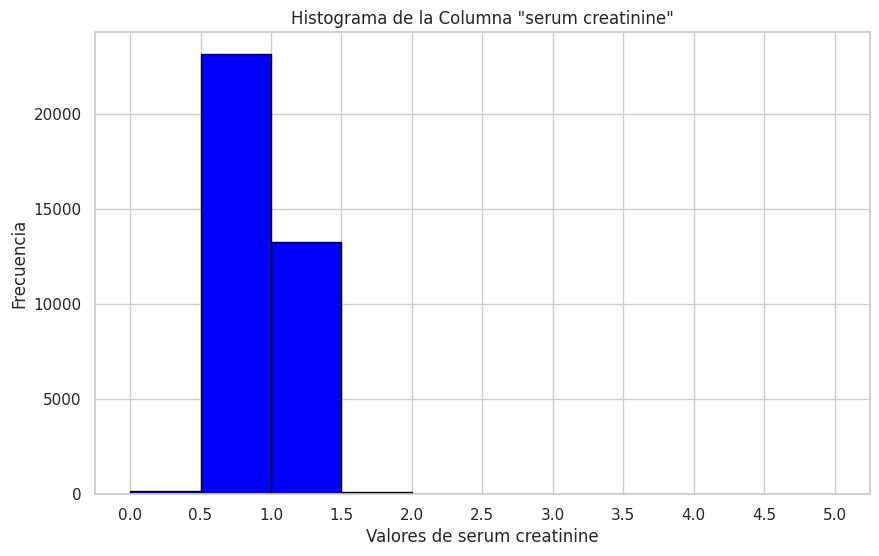

In [ ]:
#Adultos:
#Normal: 0.6 a 1.3 miligramos por decilitro (mg/dL)
#ALTO: mayor a 1.3
#BAJO:  menor a 0.6
print(df["serum creatinine"].value_counts())

# Supongamos que tienes un DataFrame llamado 'df' y quieres hacer un histograma de la columna 'serum creatinine'
serum_creatinine_data = df['serum creatinine']

# Configura el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crea el histograma
plt.hist(serum_creatinine_data, bins=np.arange(0, 5.5, 0.5), color='blue', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Histograma de la Columna "serum creatinine"')
plt.xlabel('Valores de serum creatinine')
plt.ylabel('Frecuencia')

# Establece los límites y el espaciado del eje x
plt.xticks(np.arange(0, 5.5, 0.5))

# Muestra el histograma
plt.show()


In [ ]:
df = df[(df['serum creatinine'] > 0.3) & (df['serum creatinine'] < 1.7)]

0.9    7511
0.8    6920
1.0    6473
0.7    4854
1.1    4075
0.6    2925
1.2    1920
0.5     954
1.3     605
1.4     191
0.4     131
1.5      54
1.6      25
Name: serum creatinine, dtype: int64


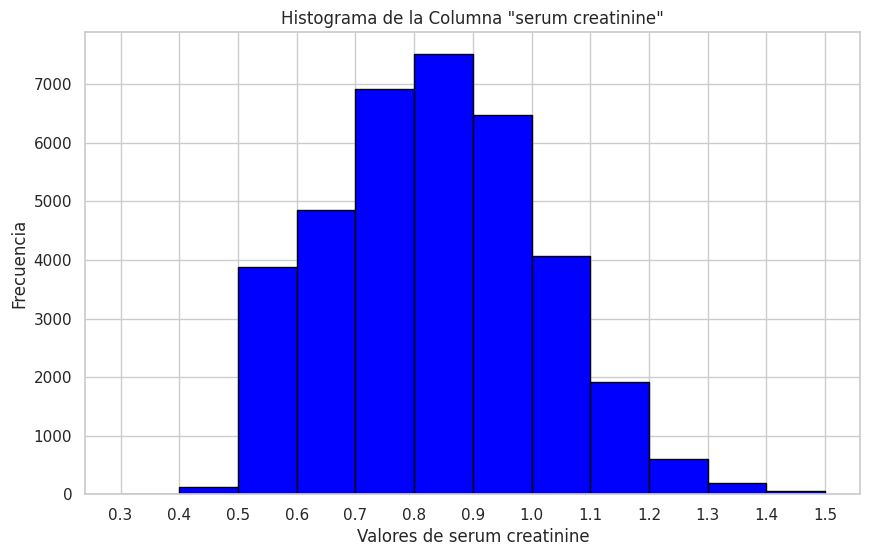

In [ ]:
#Adultos:
#Normal: 0.6 a 1.3 miligramos por decilitro (mg/dL)
#ALTO: mayor a 1.3
#BAJO:  menor a 0.6
print(df["serum creatinine"].value_counts())

# Supongamos que tienes un DataFrame llamado 'df' y quieres hacer un histograma de la columna 'serum creatinine'
serum_creatinine_data = df['serum creatinine']

# Configura el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crea el histograma
plt.hist(serum_creatinine_data, bins=np.arange(0.3, 1.6, 0.1), color='blue', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Histograma de la Columna "serum creatinine"')
plt.xlabel('Valores de serum creatinine')
plt.ylabel('Frecuencia')

# Establece los límites y el espaciado del eje x
plt.xticks(np.arange(0.3, 1.6, 0.1))

# Muestra el histograma
plt.show()

# Análisis de AST

20     2501
21     2421
22     2341
19     2335
18     2191
       ... 
292       1
128       1
315       1
225       1
387       1
Name: AST, Length: 182, dtype: int64


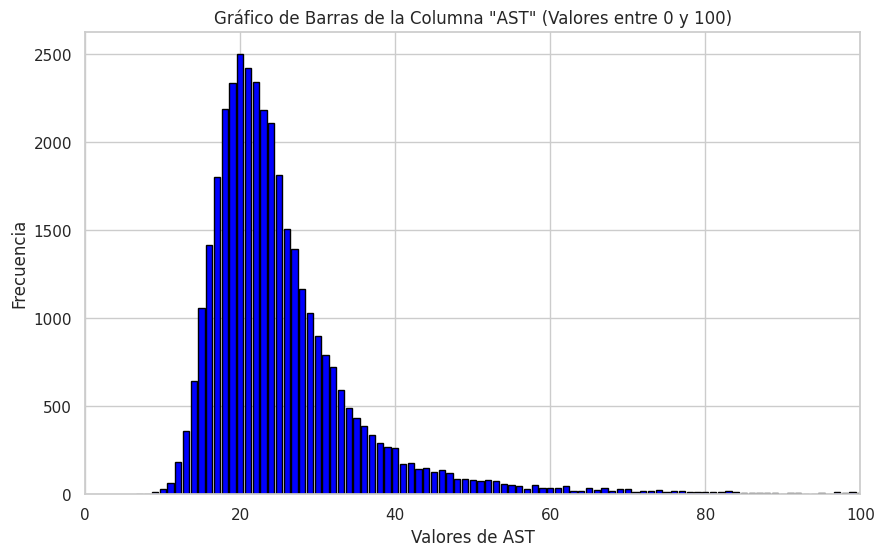

Frecuencia de valores menores a 10 en la columna "AST":
7     2
8     1
9    15
Name: AST, dtype: int64
Frecuencia de valores mayores a 80 en la columna "AST":
81      13
82      10
83      17
84      14
85       9
        ..
778      1
841      1
976      1
981      1
1090     2
Name: AST, Length: 108, dtype: int64


In [ ]:
#normal: 8 a 33 U/L.
#ALTO: mayor a 40

print(df["AST"].value_counts())
ast_data = df['AST']

# Configura el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Filtra los valores de 'AST' que están dentro del rango 0-100
ast_data_filtered = ast_data[(ast_data >= 0) & (ast_data <= 100)]

# Cuenta la frecuencia de cada valor en 'AST' dentro del rango
frecuencia_valores = ast_data_filtered.value_counts().sort_index()

# Extrae los valores únicos de 'AST' como etiquetas del eje x
valores_x = frecuencia_valores.index

# Crea el gráfico de barras
plt.bar(valores_x, frecuencia_valores, color='blue', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Gráfico de Barras de la Columna "AST" (Valores entre 0 y 100)')
plt.xlabel('Valores de AST')
plt.ylabel('Frecuencia')

# Limita el eje x al rango 0-100
plt.xlim(0, 100)

# Muestra el gráfico
plt.show()

# Filtra los valores de 'AST' que son menores a 10
valores_menores_a_10 = ast_data[ast_data < 10]

# Cuenta la frecuencia de cada valor único menor a 10
frecuencia_valores_menores_a_10 = valores_menores_a_10.value_counts().sort_index()

print(f'Frecuencia de valores menores a 10 en la columna "AST":')
print(frecuencia_valores_menores_a_10)

# Filtra los valores de 'AST' que son mayores a 80
valores_mayores_a_80 = ast_data[ast_data > 80]

# Cuenta la frecuencia de cada valor único mayor a 80
frecuencia_valores_mayores_a_80 = valores_mayores_a_80.value_counts().sort_index()

print(f'Frecuencia de valores mayores a 80 en la columna "AST":')
print(frecuencia_valores_mayores_a_80)

In [ ]:
df = df[(df['AST'] > 9) & (df['AST'] < 70)]

20    2501
21    2421
22    2341
19    2335
18    2191
23    2185
24    2112
25    1812
17    1802
26    1507
16    1414
27    1395
28    1164
15    1058
29    1030
30     900
31     793
32     724
14     643
33     595
34     490
35     433
36     388
13     361
37     336
38     294
39     266
40     264
12     183
42     175
41     171
44     149
43     145
46     140
45     126
47     121
48      88
49      84
50      80
52      80
51      76
53      74
11      63
54      60
58      52
55      50
62      49
56      45
61      38
65      36
59      35
67      33
60      33
57      29
10      29
69      27
66      26
64      20
68      17
63      16
Name: AST, dtype: int64


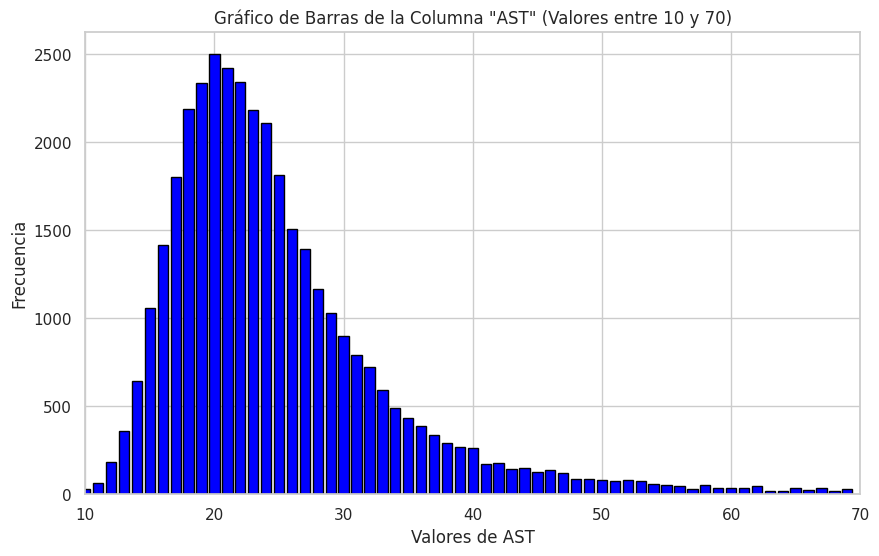

In [ ]:
print(df["AST"].value_counts())
ast_data = df['AST']

# Configura el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Filtra los valores de 'AST' que están dentro del rango 10-70
ast_data_filtered = ast_data[(ast_data > 9) & (ast_data <= 70)]

# Cuenta la frecuencia de cada valor en 'AST' dentro del rango
frecuencia_valores = ast_data_filtered.value_counts().sort_index()

# Extrae los valores únicos de 'AST' como etiquetas del eje x
valores_x = frecuencia_valores.index

# Crea el gráfico de barras
plt.bar(valores_x, frecuencia_valores, color='blue', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Gráfico de Barras de la Columna "AST" (Valores entre 10 y 70)')
plt.xlabel('Valores de AST')
plt.ylabel('Frecuencia')

# Limita el eje x al rango 10-70
plt.xlim(10, 70)

# Muestra el gráfico
plt.show()


# Análisis de ALT

15      1814
16      1752
18      1682
17      1678
14      1647
        ... 
165        1
158        1
200        1
161        1
2914       1
Name: ALT, Length: 162, dtype: int64


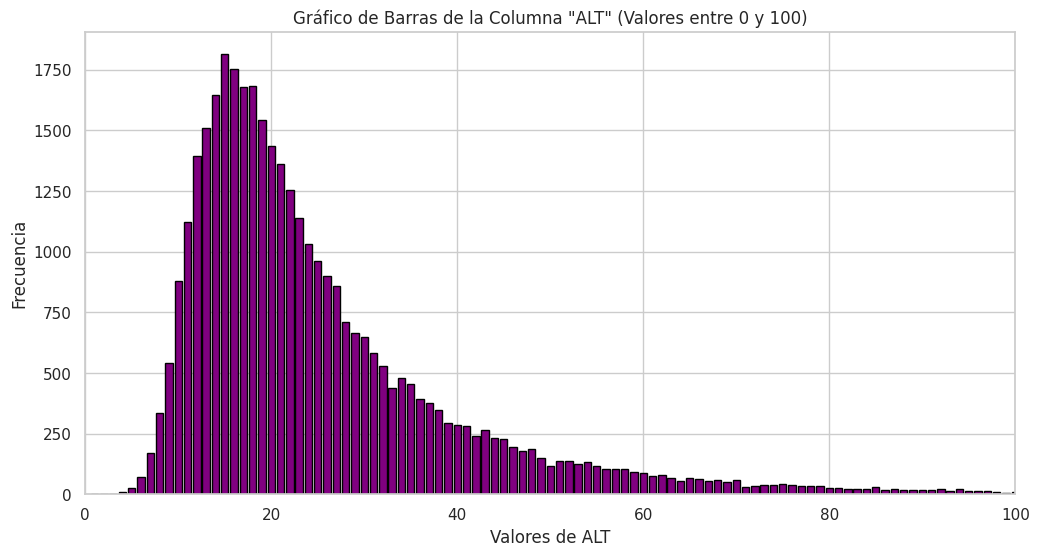

In [ ]:
#Normal: es de 4 a 36 U/L.
print(df["ALT"].value_counts())

# Supongamos que tienes un DataFrame llamado 'df' y quieres crear un gráfico de barras de la columna 'ALT'
alt_data = df['ALT']

# Configura el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Filtra los valores de 'ALT' que están dentro del rango 0-100
alt_data_filtered = alt_data[(alt_data >= 0) & (alt_data <= 100)]

# Cuenta la frecuencia de cada valor en 'ALT' dentro del rango
frecuencia_valores = alt_data_filtered.value_counts().sort_index()

# Extrae los valores únicos de 'ALT' como etiquetas del eje x
valores_x = frecuencia_valores.index

# Crea el gráfico de barras
plt.bar(valores_x, frecuencia_valores, color='purple', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Gráfico de Barras de la Columna "ALT" (Valores entre 0 y 100)')
plt.xlabel('Valores de ALT')
plt.ylabel('Frecuencia')

# Limita el eje x al rango 0-100
plt.xlim(0, 100)

# Muestra el gráfico
plt.show()

In [ ]:
df = df[(df['ALT'] > 4) & (df['ALT'] <= 70)]

15    1814
16    1752
18    1682
17    1678
14    1647
      ... 
68      59
64      55
67      54
69      52
5       26
Name: ALT, Length: 66, dtype: int64


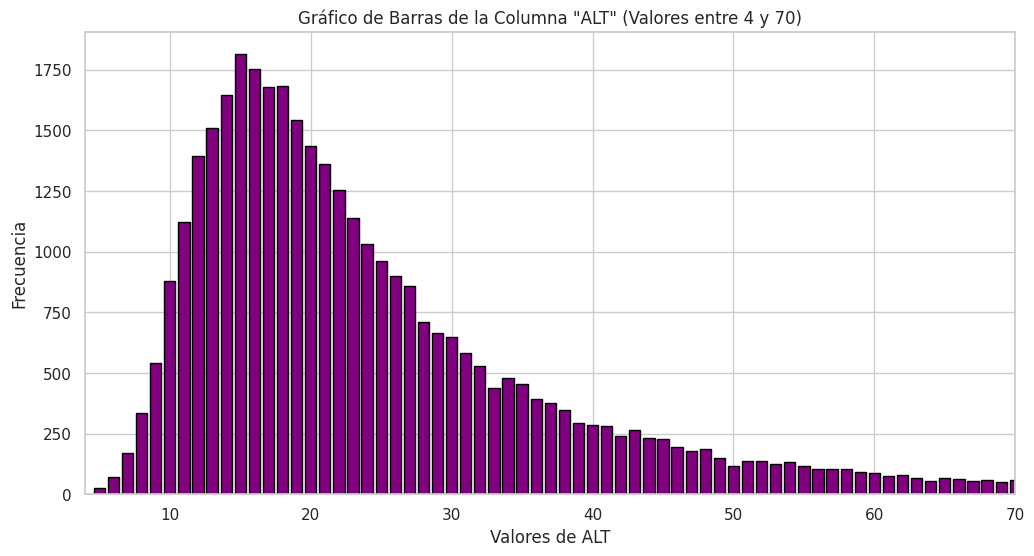

In [ ]:
#Normal: es de 4 a 36 U/L.
print(df["ALT"].value_counts())

# Supongamos que tienes un DataFrame llamado 'df' y quieres crear un gráfico de barras de la columna 'ALT'
alt_data = df['ALT']

# Configura el tamaño del gráfico
plt.figure(figsize=(12, 6))

alt_data_filtered = alt_data

# Cuenta la frecuencia de cada valor en 'ALT' dentro del rango
frecuencia_valores = alt_data_filtered.value_counts().sort_index()

# Extrae los valores únicos de 'ALT' como etiquetas del eje x
valores_x = frecuencia_valores.index

# Crea el gráfico de barras
plt.bar(valores_x, frecuencia_valores, color='purple', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Gráfico de Barras de la Columna "ALT" (Valores entre 4 y 70)')
plt.xlabel('Valores de ALT')
plt.ylabel('Frecuencia')

# Limita el eje x al rango 4-70
plt.xlim(4, 70)

# Muestra el gráfico
plt.show()

# Análisis de GTP

16     1378
14     1364
15     1342
17     1307
18     1294
       ... 
344       1
503       1
446       1
448       1
216       1
Name: Gtp, Length: 344, dtype: int64


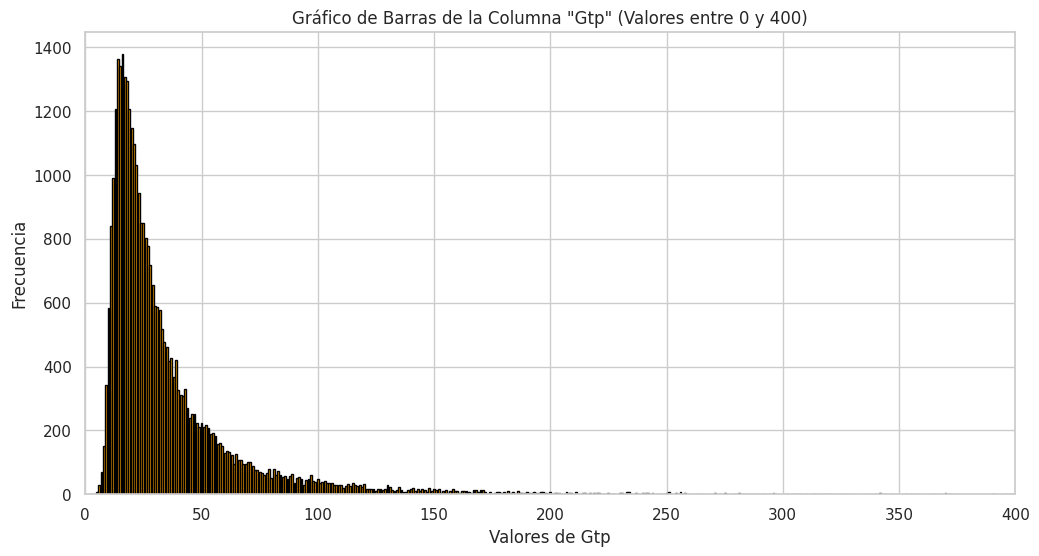

In [ ]:
#NORMAL: 7 a 38 U/L para mujeres, y de 7 a 43 U/L para hombres.
print(df["Gtp"].value_counts())

# Supongamos que tienes un DataFrame llamado 'df' y quieres crear un gráfico de barras de la columna 'Gtp'
gtp_data = df['Gtp']

# Configura el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Filtra los valores de 'Gtp' que están dentro del rango 0-400
gtp_data_filtered = gtp_data[(gtp_data >= 0) & (gtp_data <= 400)]

# Cuenta la frecuencia de cada valor en 'Gtp' dentro del rango
frecuencia_valores = gtp_data_filtered.value_counts().sort_index()

# Extrae los valores únicos de 'Gtp' como etiquetas del eje x
valores_x = frecuencia_valores.index

# Crea el gráfico de barras
plt.bar(valores_x, frecuencia_valores, color='orange', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Gráfico de Barras de la Columna "Gtp" (Valores entre 0 y 400)')
plt.xlabel('Valores de Gtp')
plt.ylabel('Frecuencia')

# Limita el eje x al rango 0-400
plt.xlim(0, 400)

# Muestra el gráfico
plt.show()


In [ ]:
df = df[(df['Gtp'] > 5) & (df['Gtp'] <= 120)]

16     1378
14     1364
15     1342
17     1307
18     1294
       ... 
114      27
117      26
112      26
119      23
111      21
Name: Gtp, Length: 115, dtype: int64


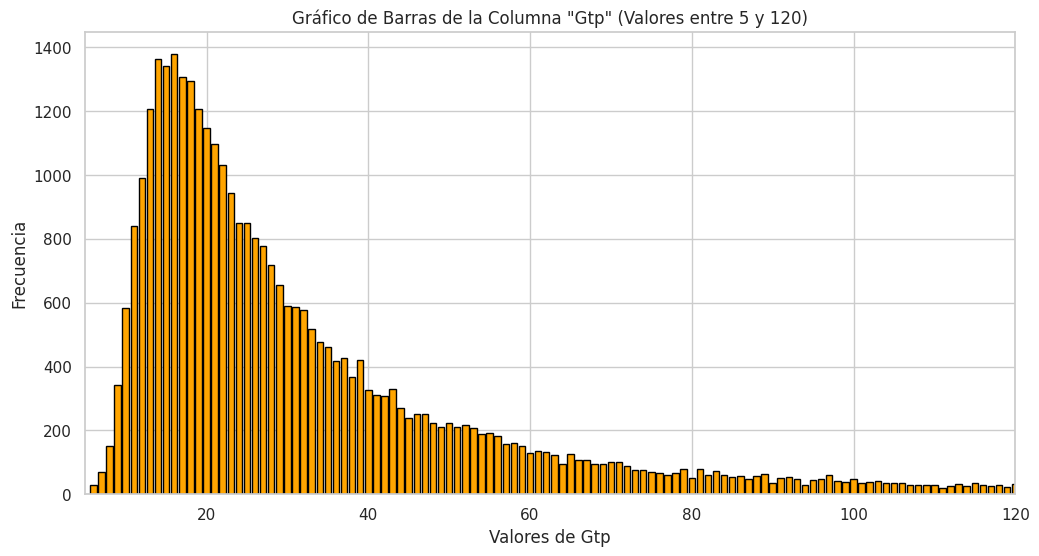

In [ ]:
#NORMAL: 7 a 38 U/L para mujeres, y de 7 a 43 U/L para hombres.
print(df["Gtp"].value_counts())

# Supongamos que tienes un DataFrame llamado 'df' y quieres crear un gráfico de barras de la columna 'Gtp'
gtp_data = df['Gtp']

# Configura el tamaño del gráfico
plt.figure(figsize=(12, 6))

gtp_data_filtered = gtp_data

# Cuenta la frecuencia de cada valor en 'Gtp' dentro del rango
frecuencia_valores = gtp_data_filtered.value_counts().sort_index()

# Extrae los valores únicos de 'Gtp' como etiquetas del eje x
valores_x = frecuencia_valores.index

# Crea el gráfico de barras
plt.bar(valores_x, frecuencia_valores, color='orange', edgecolor='black')

# Configura los títulos y etiquetas
plt.title('Gráfico de Barras de la Columna "Gtp" (Valores entre 5 y 120)')
plt.xlabel('Valores de Gtp')
plt.ylabel('Frecuencia')

# Limita el eje x al rango
plt.xlim(5, 120)

# Muestra el gráfico
plt.show()


# Análisis de Caries

0    26815
1     7247
Name: dental caries, dtype: int64


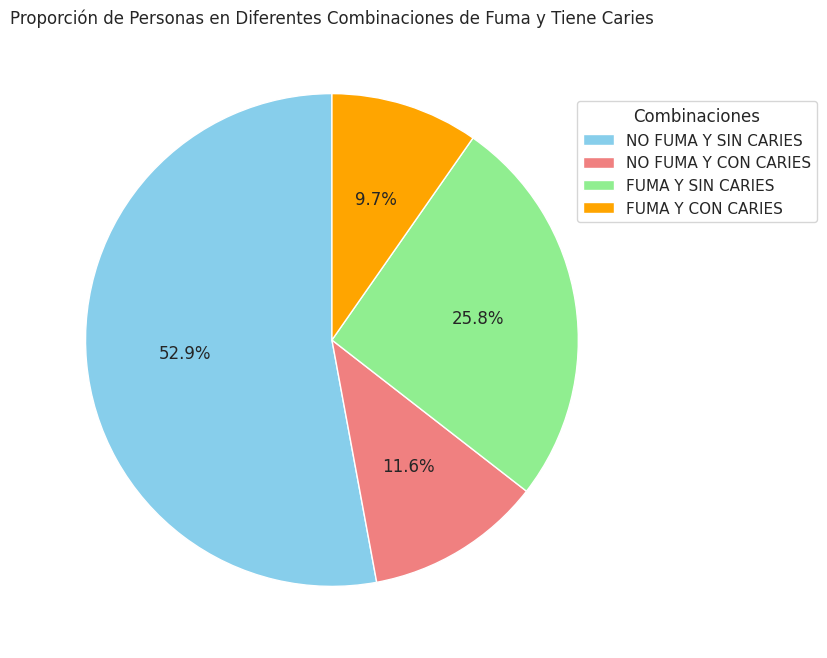

In [ ]:
#COLUMNAS: dental caries VARIABLES BINARIAS
print(df["dental caries"].value_counts())
#0: no tiene caries; 1: tiene caries

# Contar el número de personas en cada categoría
conteo_combinaciones = df.groupby(['smoking', 'dental caries']).size().unstack(fill_value=0)

# Crear un gráfico de torta
plt.figure(figsize=(8, 8))
colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange']

# Crear el gráfico de torta
plt.pie(conteo_combinaciones.values.flatten() , autopct='%1.1f%%', colors=colors, startangle=90)

# Añadir leyenda
plt.legend(title='Combinaciones', bbox_to_anchor=(1.3,0.9), labels= ["NO FUMA Y SIN CARIES","NO FUMA Y CON CARIES","FUMA Y SIN CARIES","FUMA Y CON CARIES"], loc='upper right')

plt.title('Proporción de Personas en Diferentes Combinaciones de Fuma y Tiene Caries')
plt.show()

# Análisis de Fumador

0    21965
1    12097
Name: smoking, dtype: int64


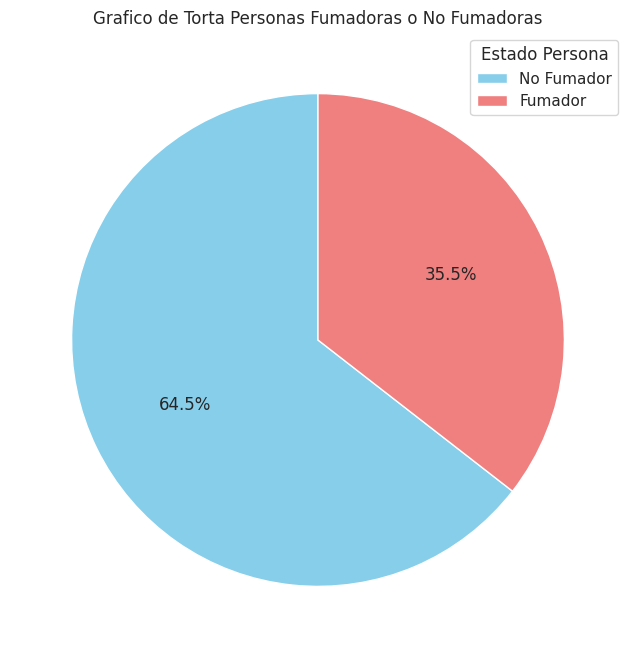

In [ ]:
#COLUMNAS: smoking VARIABLES BINARIAS
print(df["smoking"].value_counts())
#0: no fuma; 1: fuma

# Contar el número de personas que fuman y no fuman
conteo_fumadores = df['smoking'].value_counts()

# Crear un gráfico de torta
plt.figure(figsize=(8, 8))
plt.pie(conteo_fumadores,  autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=90)
plt.title('Grafico de Torta Personas Fumadoras o No Fumadoras')
plt.legend(title='Estado Persona', labels=["No Fumador","Fumador"], loc='upper right')
plt.show()

# Conclusiones de los analisis (PARA QUE EL 'df' ESTE LISTO PARA EL USO DE LOS MODELOS DE CLASIFICACION)

In [4]:

#SE CREA LA COLUMNA "IMC"
# Añadir una nueva columna 'IMC' al DataFrame
# {Bajo peso: IMC menor a 18.5} {Peso normal (saludable): IMC entre 18.5 y 24.9} {Sobrepeso: IMC entre 25 y 29.9}
# {Obesidad: IMC de 30 o superior}
df['IMC'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)
df['IMC'] = df['IMC'].round(2).astype(int)
# 'IMC' se calculará como peso en kg / (altura en metros)^2

#SE ELIMINARA LOS VALORES  DE ESTA COLUMNA QUE SEAN MAYORES A 39 y MENORES A 14  QUE NO AYUDA AL ANALISIS
df = df[(df["IMC"] < 39 )]
df = df[(df["IMC"] > 14 )]

#Se eliminan las columas sobre la medicion de la cintura (waist(cm)) y los oidos tanto izquierdo como derecho
#Ya que las mismas no nos proporciona informacion valiosa para la hipotesis planteada
columnas_a_eliminar = ["waist(cm)", "hearing(left)", "hearing(right)"]

df = df.drop(columnas_a_eliminar, axis=1)

#Eliminando las columnas sobre la altura y el peso (se trabaja directamente sobre la columna IMC)
columnas_a_eliminar = ["height(cm)", "weight(kg)"]
# Utiliza el método drop para eliminar las columnas
df = df.drop(columns=columnas_a_eliminar)

#ANALISIS DE "OJOS (IZQUIEDO Y DERECHO)"
#SE ELIMINARA LOS VALORES  DE ESTA COLUMNA QUE ESTEN FUERA DEL RANGO (9.9) PORQUE SON VALORES ATIPICOS Y MENORES Y NO AYUDA AL ANALISIS
# Filtrar el DataFrame para incluir solo los valores dentro del rango deseado
df = df[(df["eyesight(left)"] >= 0.0) & (df["eyesight(left)"] <= 2.0)]

# Filtrar el DataFrame para incluir solo los valores dentro del rango deseado
df = df[(df["eyesight(right)"] >= 0.0) & (df["eyesight(right)"] <= 2.0)]

#ANALISIS DE "EDAD"
#SE ELIMINARA LOS VALORES  DE ESTA COLUMNA QUE SEAN MAYORES A 80 QUE NO AYUDA AL ANALISIS
df = df[(df["age"] < 80 )]

#ANALISIS DE "PRESION DIASTOLICA (RELAXATION)"
#Valores atipicos: menores a 50 y mayores a 110
df = df[(df['relaxation'] >= 50) & (df['relaxation'] <= 110)]

#ANALISIS DE "AZUCAR EN SANGRE"
df = df[(df['fasting blood sugar'] >= 60) & (df['fasting blood sugar'] <= 175)]

#ANALISIS DE "COLESTEROL"
df = df[(df['Cholesterol'] >= 90) & (df['Cholesterol'] <= 330)]

#ANALISIS DE "TRIGLICERIDOS"
df = df[(df['triglyceride'] >= 40) & (df['triglyceride'] <= 410)]

#ANALISIS DE "HDL(CORESTEROL BUENO)"
df = df[(df['HDL'] >= 23) & (df['HDL'] <= 126)]

#ANALISIS DE "LDL(CORESTEROL MALO)"
# df = df[(df['LDL'] >= 8) & (df['LDL'] <= 19)]

#ANALISIS DE "HEMOGLOBINA"
df = df[(df['hemoglobin'] >= 8) & (df['hemoglobin'] <= 19)]

#ANALISIS DE "PROTEINA EN ORINA"
# Se deberia eliminar la columna, ya que no se aclara que unidad de medicion se plantea para el analisis de esta variable.
# Ademas, los valores que aparecen en el dataset no respetan la distribucion correcta para analizar el estado de
# salud para esta columna (de 0 a 150 mg/dL o 0.15 g/L si esta en condiciones, de 150 o mas si tiene problemas)

df.drop(columns = "Urine protein", axis=1, inplace= True)


#ANALISIS DE "SERUM CREATININE"
df = df[(df['serum creatinine'] > 0.3) & (df['serum creatinine'] < 1.7)]

#ANALISIS DE "AST"
df = df[(df['AST'] > 9) & (df['AST'] < 70)]

#ANALISIS DE "ALT"
df = df[(df['ALT'] > 4) & (df['ALT'] <= 70)]

# ANALISIS DE "GTP"
df = df[(df['Gtp'] > 5) & (df['Gtp'] <= 120)]

df.head(10)

,age,eyesight(left),eyesight(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,serum creatinine,AST,ALT,Gtp,dental caries,smoking,IMC
1,20,0.7,0.9,119,79,88,211,128,71,114,15.9,1.1,19,25,30,1,0,35
4,20,1.5,0.1,109,64,100,179,200,47,92,14.9,1.2,26,28,15,0,0,22
5,60,1.0,0.9,126,75,114,177,74,98,64,13.9,1.0,47,23,70,0,1,19
6,40,0.9,1.0,130,88,90,207,331,39,102,16.5,1.0,19,22,19,0,0,29
7,40,1.5,1.5,110,60,100,170,62,58,99,14.0,1.4,29,20,32,1,1,23
8,40,1.2,1.5,89,57,83,178,69,60,104,12.9,0.7,17,17,14,0,0,20
9,45,0.7,1.0,114,81,96,184,177,41,107,13.1,0.6,22,15,56,0,0,22
10,40,0.5,0.5,130,80,94,154,91,63,73,14.3,0.5,19,13,9,0,1,23
13,75,0.5,0.1,114,68,86,230,71,72,144,12.6,0.6,26,11,12,0,0,20
14,40,1.0,1.5,101,72,78,259,105,71,167,13.4,1.0,23,16,18,0,0,17


# FIN ENTREGA 2

In [4]:
print(f"El DataFrame tenía 38984 filas.")
print(f"El DataFrame tiene {df.shape[0]} filas.")
print(f"Del DataFrame se eliminaron {38984 - df.shape[0]} filas.")

El DataFrame tenía 38984 filas.
El DataFrame tiene 34285 filas.
Del DataFrame se eliminaron 4699 filas.


# **MODELO PARA SMOKING**

---



In [5]:
# Supongamos que 'smoking' es la variable objetivo y las demás columnas son características
features = df.drop('smoking', axis=1)
target = df['smoking']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [6]:

# Mostrar las columnas del DataFrame
print("\nColumnas:")
print(df.columns)


Columnas:
Index(['age', 'eyesight(left)', 'eyesight(right)', 'systolic', 'relaxation',
       'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL',
       'hemoglobin', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries',
       'smoking', 'IMC'],
      dtype='object')


# Regresion Logistica

In [6]:
# Hiperparámetros a probar (ajusta esto según tus necesidades)
hyperparameters = {'C': [0.01]}

# Inicializar el modelo de regresión logística
logreg = LogisticRegression(max_iter=1000, penalty='l2', solver='liblinear', random_state=42)
# Utilizar búsqueda en cuadrícula para probar diferentes hiperparámetros
grid_search = GridSearchCV(logreg, hyperparameters, cv=5)
# Luego, ajusta el modelo con los datos escalados
grid_search.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", grid_search.best_params_)

# Predecir en el conjunto de prueba
y_pred = grid_search.predict(X_test)

# Evaluar la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)

Mejores hiperparámetros: {'C': 0.01}
Precisión del modelo: 0.7132856934519469


In [ ]:
import pickle

# Supongamos que ya tienes tu modelo entrenado y lo guardas en la variable 'modelo'
modelo = grid_search # Este es el nombre de tu modelo

# Guardar el modelo en un archivo utilizando pickle
with open('/Desktop/formularioCDD', 'wb') as archivo:
    pickle.dump(modelo, archivo)


FileNotFoundError: ignored

In [ ]:
from flask import Flask, render_template, request
import pickle

# Cambiar modelo.pickle por el nombre de tu archivo
# Cargar el modelo desde el archivo pickle
with open('/formularioCDD/public/index.html', 'rb') as archivo:
    modelo_cargado = pickle.load(archivo)

app = Flask(__name__)

@app.route('/')
def index():
    return render_template('/formularioCDD/public/index.html')

@app.route('/predict', methods=['POST'])
def predict():
    # Obtener los parámetros enviados desde el formulario
    # Aquí se deben ajustar a las columnas que estás utilizando en tu modelo
    edad = request.form['edad']
    imc = request.form['imc']
    vistaOjoIzq = request.form['ojoIzquierdo']
    vistaOjoDer = request.form['ojoDerecho']
    presionSistolica = request.form['presionSistolica']
    presionDiastolica = request.form['presionDiastolica']
    glucemia = request.form['glucemia']
    colesterol = request.form['colesterol']
    trigliceridos = request.form['trigliceridos']
    hdl = request.form['hdl']
    ldl = request.form['ldl']
    hemoglobina = request.form['hemoglobina']
    serumCreatinine = request.form['serumCreatinine']
    ast = request.form['ast']
    alt = request.form['alt']
    gtp = request.form['gtp']
    caries = request.form['caries']

    # Realizar la predicción utilizando el modelo cargado
    resultado = modelo_cargado.predict([[edad,imc,vistaOjoIzq,vistaOjoDer,presionSistolica,
                                         presionDiastolica,glucemia,colesterol,trigliceridos,hdl,ldl,hemoglobina,
                                         serumCreatinine,ast,alt,gtp,caries]])
    return render_template('/formularioCDD/public/index.html', resultado=resultado)

if __name__ == '__main__':
    app.run(debug=True, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


# Random Forest

Mejores hiperparámetros: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 111}
Precisión: 0.7831
Precision: 0.6833
Recall: 0.7353
F1 Score: 0.7084


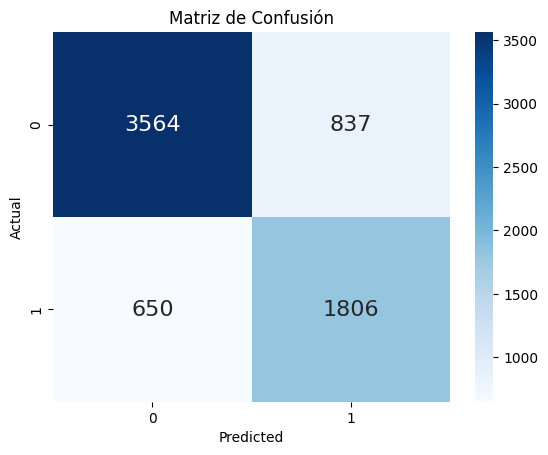

In [6]:
# Definir los hiperparámetros a probar
param_grid = {
    'n_estimators': [111],
    'max_depth': [18],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
    'bootstrap': [True],
    'criterion': ['gini']
}
# Inicializar el modelo de Random Forest
random_forest = RandomForestClassifier(class_weight='balanced',random_state=42)

# Inicializar la búsqueda en cuadrícula
grid_search = GridSearchCV(random_forest, param_grid, cv=5, scoring='accuracy')

# Realizar la búsqueda en cuadrícula en el conjunto de entrenamiento
grid_search.fit(X_train, y_train)

# Obtener el modelo con los mejores hiperparámetros
best_random_forest = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_probs = best_random_forest.predict_proba(X_test)[:, 1]

# Ajustar el umbral
umbral = 0.49
y_pred_adjusted = np.where(y_probs >= umbral, 1, 0)

# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", grid_search.best_params_)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred_adjusted)
precision = precision_score(y_test, y_pred_adjusted)
recall = recall_score(y_test, y_pred_adjusted)
f1 = f1_score(y_test, y_pred_adjusted)

# Imprimir resultados
print(f'Precisión: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
# Calcular y mostrar la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_adjusted)

# Graficar la matriz de confusión
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

In [7]:
import pickle

# Supongamos que ya tienes tu modelo entrenado y lo guardas en la variable 'modelo'
modelo = best_random_forest # Este es el nombre de tu modelo

# Guardar el modelo en un archivo utilizando pickle
with open('C:/Users/gordo/OneDrive - frc.utn.edu.ar/Ciencia de Datos - 5K2/CDD/formularioCDD/modelo.pickle', 'wb') as archivo:
    pickle.dump(modelo, archivo)

In [10]:
from flask import Flask, render_template, request
import pickle
import os

# Load the model from the pickle file
with open('C:/Users/gordo/OneDrive - frc.utn.edu.ar/Ciencia de Datos - 5K2/CDD/formularioCDD/modelo.pickle', 'rb') as archivo:
    modelo_cargado = pickle.load(archivo)

app = Flask(__name__, template_folder='C:/Users/gordo/OneDrive - frc.utn.edu.ar/Ciencia de Datos - 5K2/CDD/formularioCDD/public')

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    # Obtain parameters from the form
    age = request.form['age']
    eyesightLeft = request.form['eyesightLeft']
    eyesightRight = request.form['eyesightRight']
    systolic = request.form['systolic']
    relaxation = request.form['relaxation']
    fasting_blood_sugar	 = request.form['fastingBloodSugar']
    Cholesterol	 = request.form['cholesterol']
    triglyceride = request.form['triglyceride']
    hdl = request.form['hdl']
    lDL = request.form['ldl']
    hemoglobin = request.form['hemoglobin']
    serum_creatinine = request.form['serumCreatinine']
    aST = request.form['ast']
    aLT = request.form['alt']
    gtp = request.form['gtp']
    dental_caries = request.form['dentalCaries']
    iMC = request.form['imc']

    # Make the prediction using the loaded model
    resultado = modelo_cargado.predict([[age, eyesightLeft, eyesightRight, systolic, relaxation,
                                         fasting_blood_sugar, Cholesterol, triglyceride, hdl, lDL, hemoglobin, 
                                         serum_creatinine, aST, aLT, gtp, dental_caries, iMC]])
    return render_template('resultado.html', resultado=resultado)


if __name__ == '__main__':
    app.run(debug=True, use_reloader=False)


 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [14/Nov/2023 15:43:23] "GET / HTTP/1.1" 200 -
c:\Users\gordo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
127.0.0.1 - - [14/Nov/2023 15:43:28] "POST /predict HTTP/1.1" 200 -
c:\Users\gordo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
127.0.0.1 - - [14/Nov/2023 15:45:11] "POST /predict HTTP/1.1" 200 -
c:\Users\gordo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
127.0.0.1 - - [14/Nov/2023 15:46:42] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [14/Nov/202

# SVM

In [ ]:

# Definir el clasificador SVM
svm_classifier = SVC(random_state= 42)

# Definir la cuadrícula de hiperparámetros que deseas probar
param_grid = {
    'C': [10],
    'kernel':["linear", "poly", "rbf", "sigmoid", "precomputed"],
    'degree': [2, 3, 4],  # Grado del kernel polinómico
    'gamma': ['scale', 'auto', 0.1, 1],  # Parámetro gamma para el kernel RBF

}
# Inicializar la búsqueda en cuadrícula con SVM como clasificador
grid_search = GridSearchCV(estimator=svm_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# Ajustar la búsqueda en cuadrícula al conjunto de entrenamiento
grid_search.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", grid_search.best_params_)

# Obtener la mejor SVM entrenada con los mejores hiperparámetros
best_svm = grid_search.best_estimator_

# Predecir en el conjunto de prueba
y_pred = best_svm.predict(X_test)

# Evaluar la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)

# AdaBoost

Mejores hiperparámetros: {'algorithm': 'SAMME.R', 'learning_rate': 0.5, 'n_estimators': 60}
Mejor precisión: 0.740155875351562


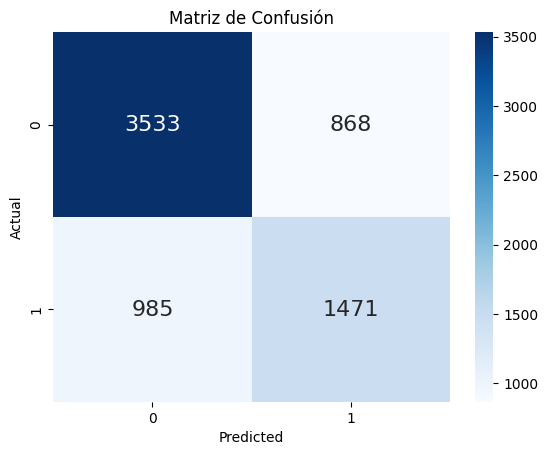

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier

param_grid = {
    'n_estimators': [20, 30, 40, 50, 60, 70],
    'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5],
    'algorithm': ['SAMME', 'SAMME.R']
}

adaboost = AdaBoostClassifier(random_state=42)
grid_search = GridSearchCV(adaboost, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor precisión:", grid_search.best_score_)

# Obtén el mejor modelo después de la búsqueda de cuadrícula
best_model = grid_search.best_estimator_

# Realiza predicciones en el conjunto de prueba
y_pred = best_model.predict(X_test)

#calcular otras metricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Imprimir resultados
print("\nOtras Metricas:")
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Calcula la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)


# Graficar la matriz de confusión
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()


# **MODELO PARA CARIES**

---



In [ ]:

# Supongamos que 'smoking' es la variable objetivo y las demás columnas son características
features = df.drop('dental caries', axis=1)
target = df['dental caries']

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Regresion Logistica

In [ ]:
# Hiperparámetros a probar (ajusta esto según tus necesidades)
hyperparameters = {'C': [0.001, 0.01, 0.1, 1]}

# Inicializar el modelo de regresión logística
logreg = LogisticRegression(max_iter=500, solver='liblinear')

# Utilizar búsqueda en cuadrícula para probar diferentes hiperparámetros

grid_search = GridSearchCV(logreg, hyperparameters, cv=5)
grid_search.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", grid_search.best_params_)

# Predecir en el conjunto de prueba
y_pred = grid_search.predict(X_test)

# Evaluar la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)


Mejores hiperparámetros: {'C': 0.001}
Precisión del modelo: 0.7780070754716981


# Random Forest

Mejores hiperparámetros: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 165}
Precisión: 0.8025
Precision: 0.7286
Recall: 0.7062
F1 Score: 0.7172


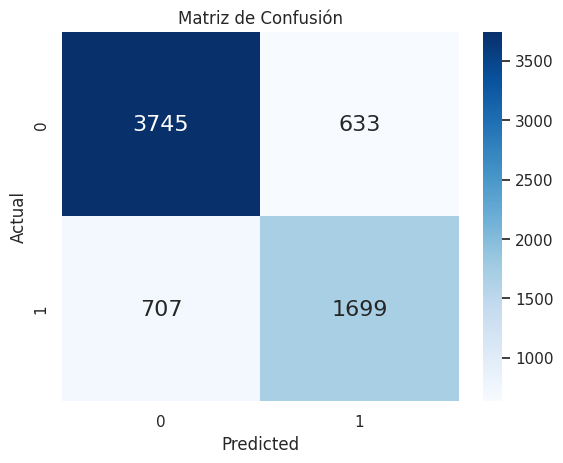

In [ ]:
# Definir los hiperparámetros a probar
param_grid = {
    'n_estimators': [165],
    'max_depth': [None],
    'min_samples_split': [5],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
    'bootstrap': [True],
    'criterion': ['entropy']
}
# Inicializar el modelo de Random Forest
random_forest = RandomForestClassifier(class_weight='balanced', random_state=42)

# Inicializar la búsqueda en cuadrícula
grid_search = GridSearchCV(random_forest, param_grid, cv=5, scoring='accuracy')

# Realizar la búsqueda en cuadrícula en el conjunto de entrenamiento
grid_search.fit(X_train, y_train)

# Obtener el modelo con los mejores hiperparámetros
best_random_forest = grid_search.best_estimator_

# Realizar predicciones en el conjunto de prueba
y_probs = best_random_forest.predict_proba(X_test)[:, 1]

# Ajustar el umbral
umbral = 0.49
y_pred_adjusted = np.where(y_probs >= umbral, 1, 0)

# Mostrar los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", grid_search.best_params_)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred_adjusted)
precision = precision_score(y_test, y_pred_adjusted)
recall = recall_score(y_test, y_pred_adjusted)
f1 = f1_score(y_test, y_pred_adjusted)

# Imprimir resultados
print(f'Precisión: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Calcular y mostrar la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_adjusted)

# Graficar la matriz de confusión
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

# AdaBoost

Mejores hiperparámetros: {'algorithm': 'SAMME.R', 'learning_rate': 0.5, 'n_estimators': 20}
Mejor precisión: 0.7880997557053323

Otras Metricas:
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


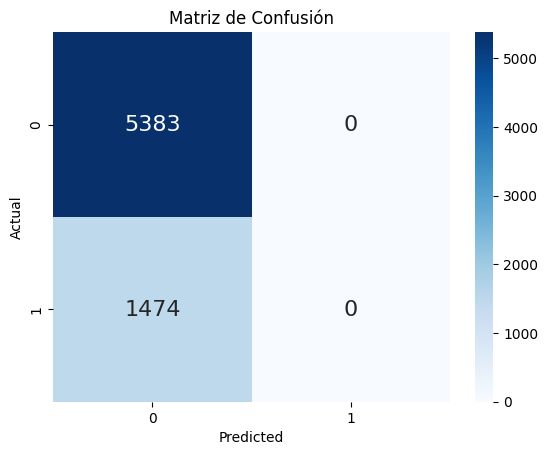

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier

param_grid = {
    'n_estimators': [20, 30, 40, 50, 60, 70],
    'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5],
    'algorithm': ['SAMME', 'SAMME.R']
}

adaboost = AdaBoostClassifier(random_state=42)
grid_search = GridSearchCV(adaboost, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor precisión:", grid_search.best_score_)

# Obtén el mejor modelo después de la búsqueda de cuadrícula
best_model = grid_search.best_estimator_

# Realiza predicciones en el conjunto de prueba
y_pred = best_model.predict(X_test)

#calcular otras metricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Imprimir resultados
print("\nOtras Metricas:")
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Calcula la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# Graficar la matriz de confusión
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
import pickle

# Supongamos que ya tienes tu modelo entrenado y lo guardas en la variable 'modelo'
modelo = gradient_boosting # Este es el nombre de tu modelo

# Guardar el modelo en un archivo utilizando pickle
with open('modelo.pickle', 'wb') as archivo:
    pickle.dump(modelo, archivo)